<a href="https://colab.research.google.com/github/anuragN2107/Walmart-Sales-Forecasting-Capstone/blob/main/Capstone_Project(Walmart).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement 1:**

A retail store that has multiple outlets across the country are facing issues in managing the inventory - to match the demand with respect to supply.

**Objective:**

1.) You are provided with the weekly sales data for their various outlets. Use statistical analysis, EDA, outlier analysis, and handle the missing values to come up with various insights that can give them a clear perspective on the following:

a.) If the weekly sales are affected by the unemployment rate, if yes - which stores are suffering the most?

b.) If the weekly sales show a seasonal trend, when and what could be the reason?

c.) Does temperature affect the weekly sales in any manner?

d.) How is the Consumer Price index affecting the weekly sales of various stores?

e.) Top performing stores according to the historical data.

f.) The worst performing store, and how significant is the difference between the highest and lowest performing stores.

2.) Use predictive modeling techniques to forecast the sales for each store for the next 12 weeks.


In [1]:
#Importing the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('/content/Walmart DataSet.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


#Data Preprocessing Steps And Inspiration

In [4]:
df.isnull().sum() # Checking the null values

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [5]:
df.shape

(6435, 8)

In [6]:
df.duplicated().sum() # Checking for duplicate values

np.int64(0)

In [7]:
#Creating a variable to store numerical columns for performing numerical analysis such as outlier detection and statistical evaluation
num_columns=df.select_dtypes(include=np.number).columns
num_columns

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment'],
      dtype='object')

In [8]:
# Since the Holiday_Flag column is categorical, it is excluded from numerical analysis
indices_to_remove = ['Holiday_Flag']  # List of categorical columns to be removed from numerical features

num_columns = num_columns.difference(indices_to_remove)  # Removing categorical columns from numerical columns using the difference function


In [9]:
num_columns

Index(['CPI', 'Fuel_Price', 'Store', 'Temperature', 'Unemployment',
       'Weekly_Sales'],
      dtype='object')

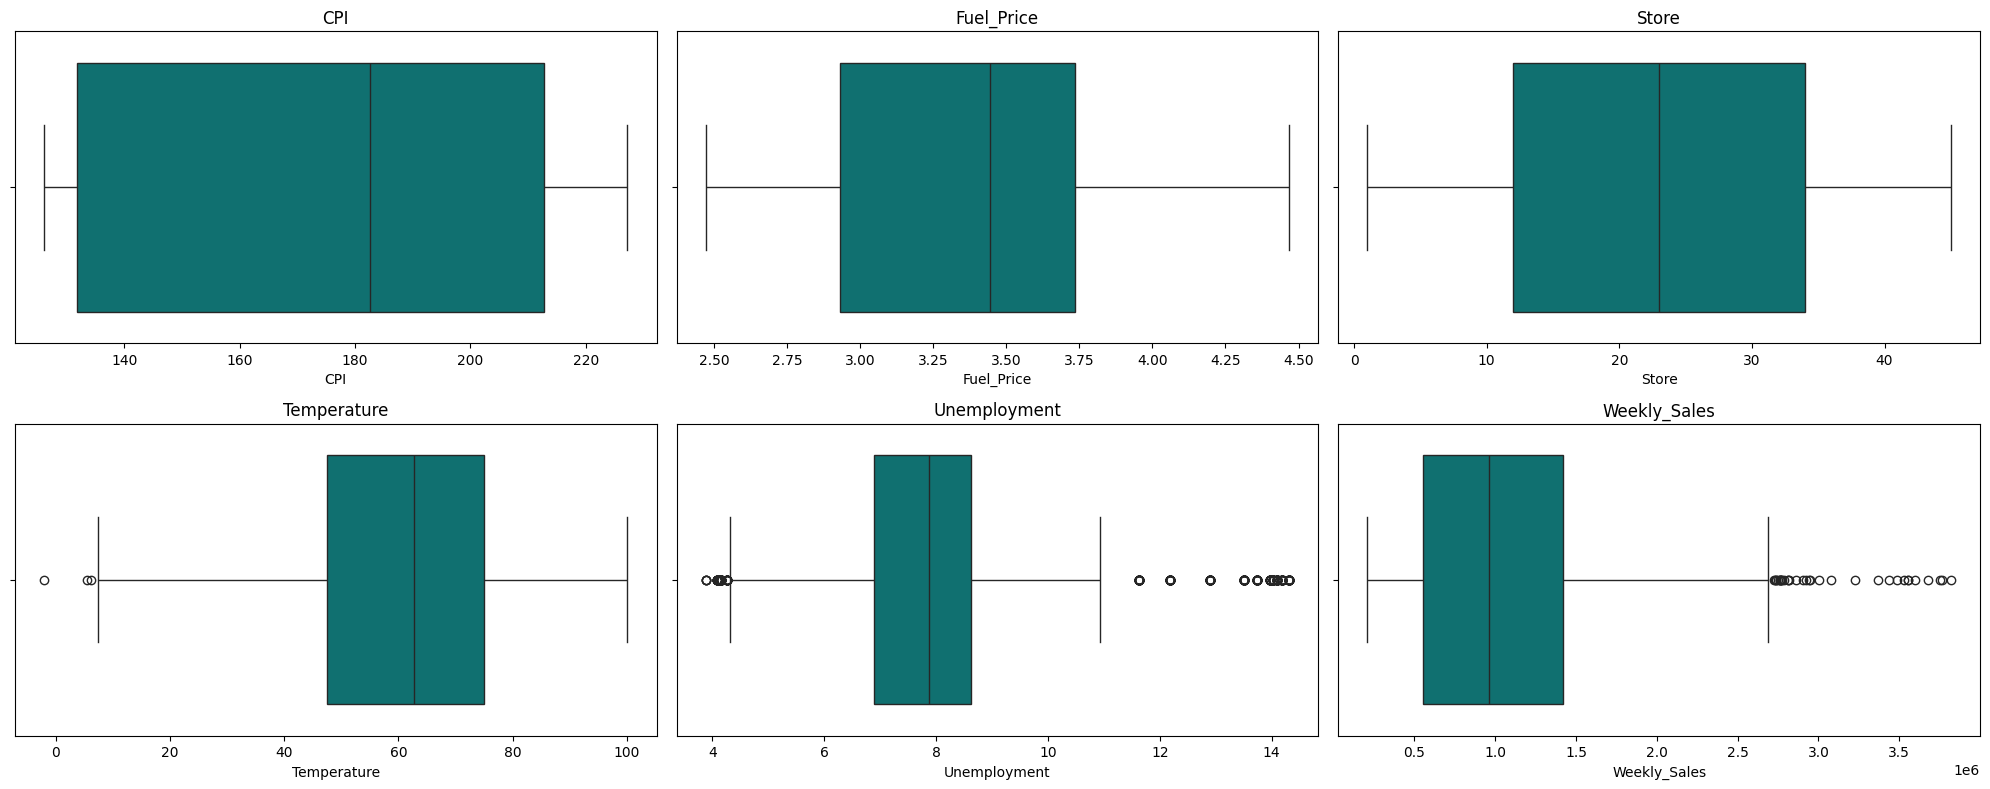

In [10]:
# Finding Outliers: Box plots are used to visualize the presence of outliers in numerical columns,
# which helps in identifying extreme values that may need to be treated.

plt.figure(figsize=(20, 8))  # Setting the figure size for multiple plots

# Looping through each numerical column to plot box plots for outlier detection
for i, col in enumerate(num_columns):
    plt.subplot(2, 3, i + 1)  # Arranging subplots in a grid format
    sns.boxplot(x=df[col], color="teal")  # Colored box plot
    plt.title(col)          # Setting the title for each subplot
    plt.tight_layout()     # Adjusting layout to prevent overlapping of plots

plt.show()  # Displaying all the plots


In [11]:
import numpy as np

# Defining a function to compute the Interquartile Range (IQR) and cap outliers
def remove_outliers(df1, col):
    # Calculating the first quartile (Q1) at the 25th percentile
    q1 = df1[col].quantile(0.25)

    # Calculating the third quartile (Q3) at the 75th percentile
    q3 = df1[col].quantile(0.75)

    # Computing the Interquartile Range (IQR)
    IQR = q3 - q1

    # Defining lower and upper bounds for outlier detection
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    # Capping values outside the bounds to the lower and upper limits
    df1[col] = np.clip(df1[col], lower_bound, upper_bound)

    return df1  # Returning the updated dataset


# Defining a function to apply outlier treatment across multiple numerical columns
def treat_outliers(df1, col_list):
    # Iterating through each numerical column and applying IQR-based capping
    for col in col_list:
        df1 = remove_outliers(df1, col)

    return df1  # Returning the dataset after outlier treatment


In [12]:
df=treat_outliers(df,num_columns) # Removing the outliers

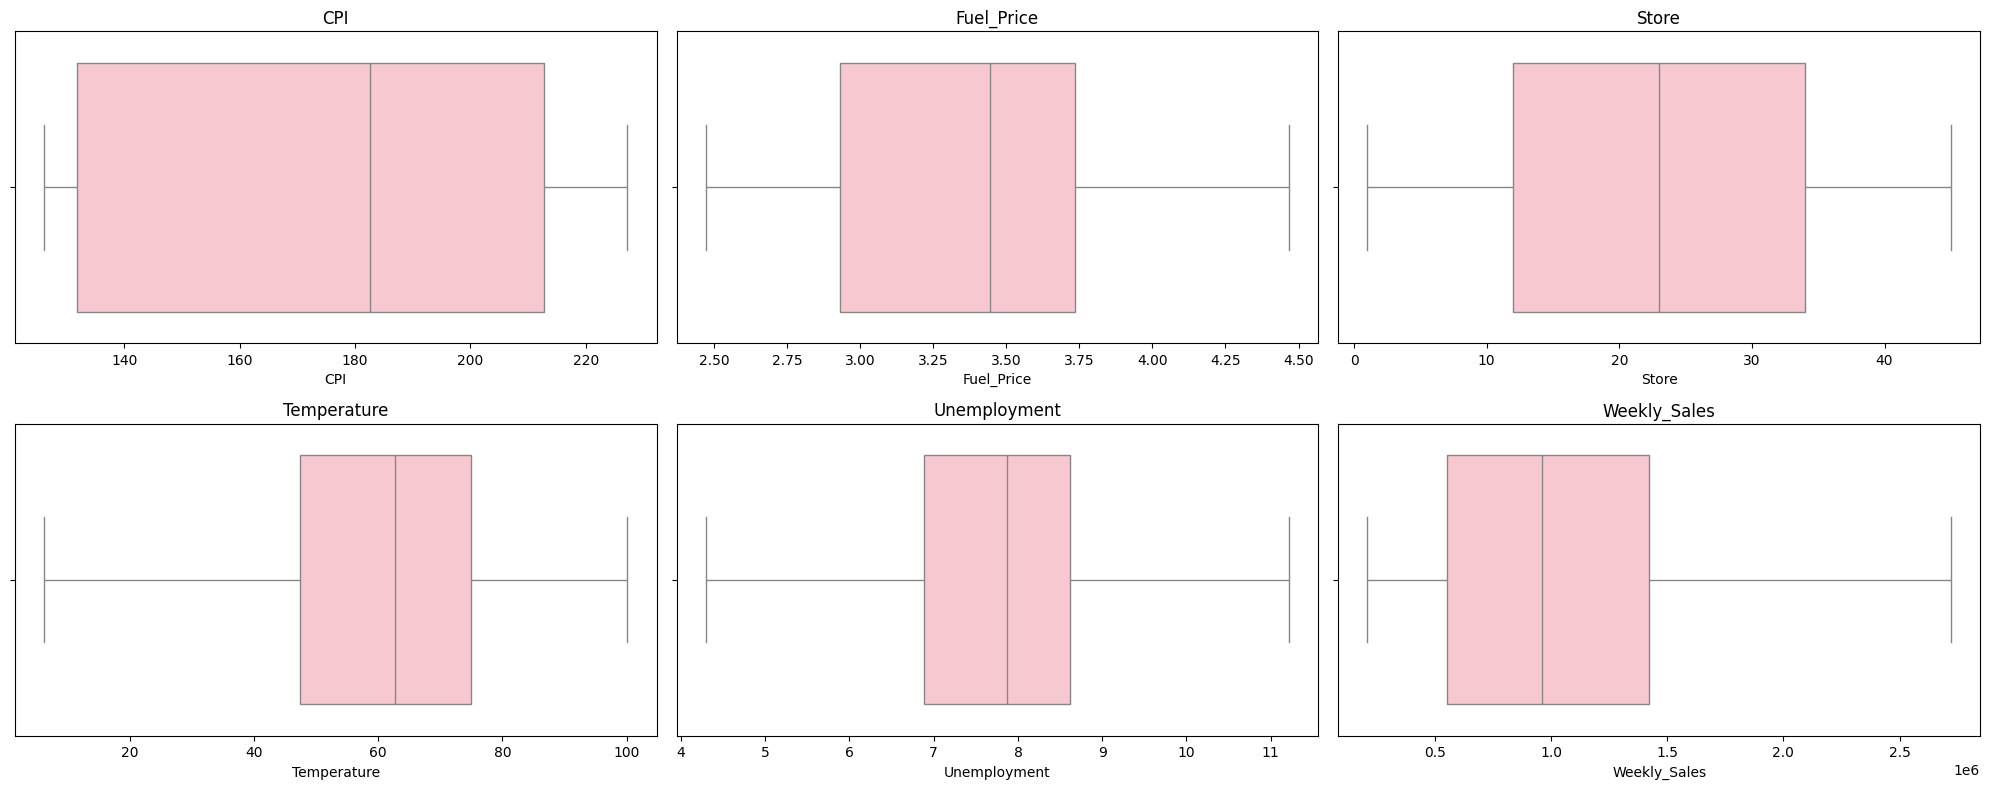

In [13]:
# Cross-checking the presence of outliers after applying outlier treatment.

plt.figure(figsize=(20, 8))  # Setting the figure size for multiple plots

for i, col in enumerate(num_columns):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=df[col], color="pink")
    plt.title(col)
    plt.tight_layout()

plt.show()


#Exploratory Data Analysis(EDA)

In [14]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


#Store V/s Weekly Sales

In [15]:
df_store_sales = df.groupby('Store')['Weekly_Sales'].sum().reset_index()

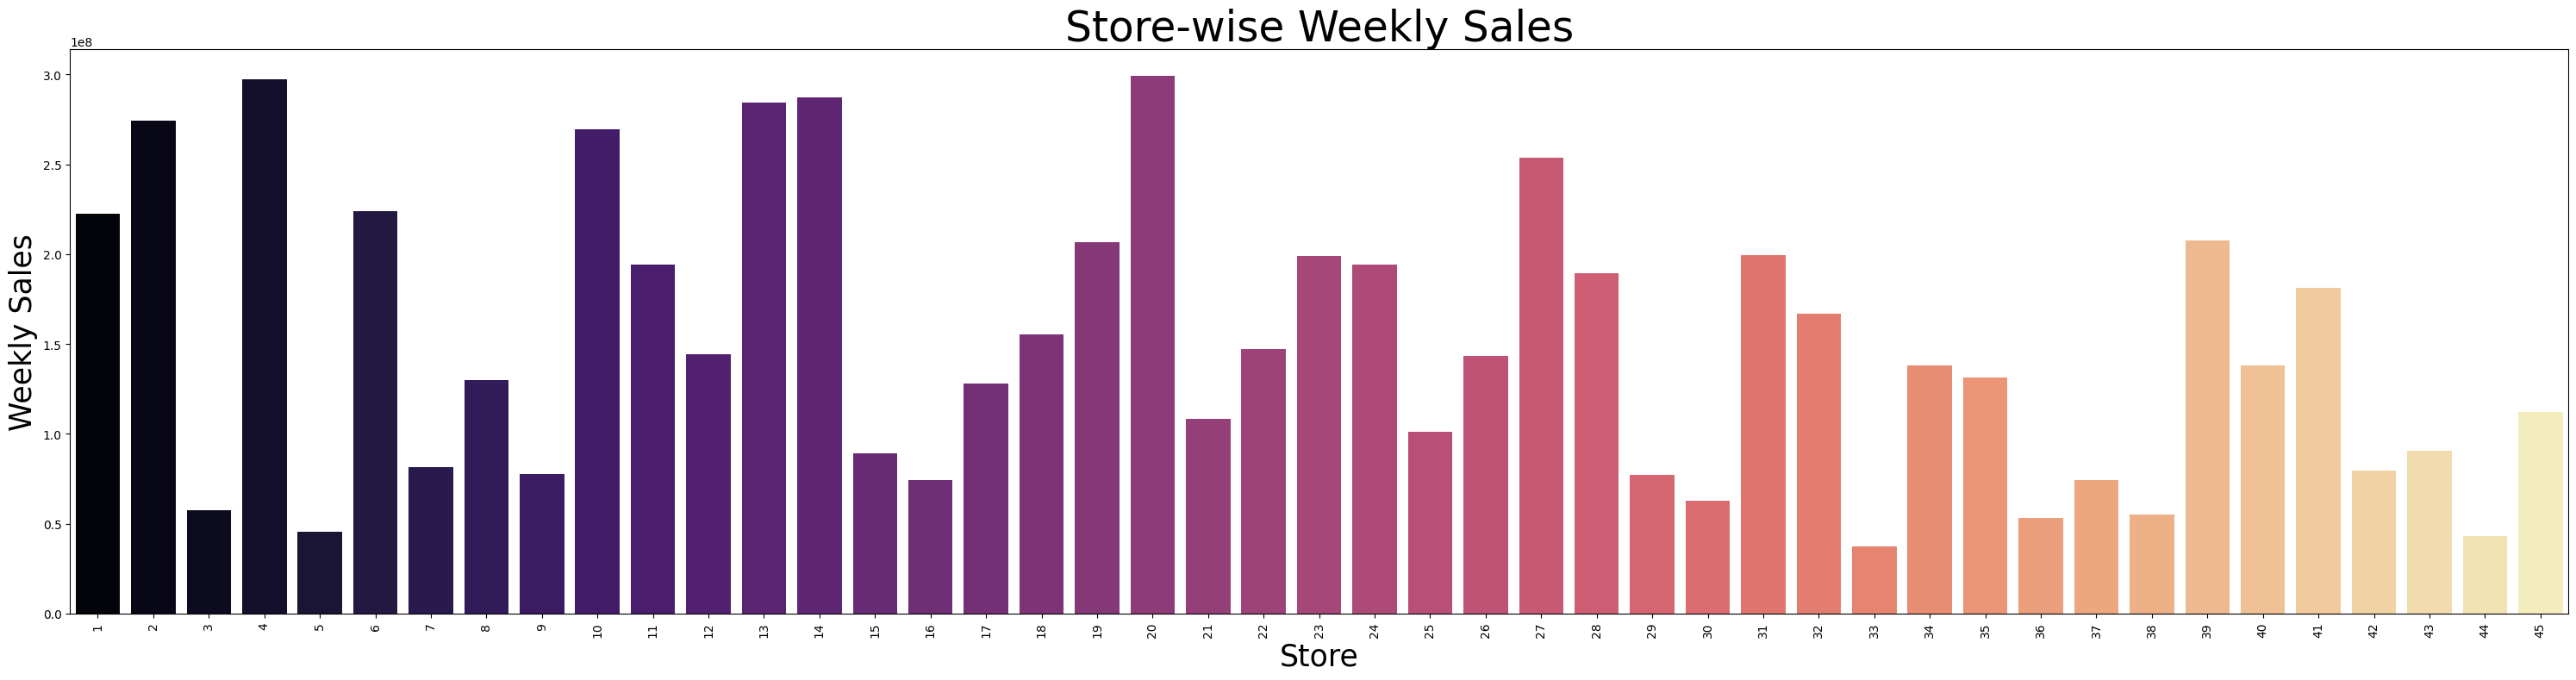

In [16]:
plt.figure(figsize=(30, 8))

sns.barplot(
    x='Store',
    y='Weekly_Sales',
    data=df_store_sales,
    palette='magma'
)

plt.title('Store-wise Weekly Sales', fontsize=35)
plt.xlabel('Store', fontsize=25)
plt.ylabel('Weekly Sales', fontsize=25)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


#Inference:
As the dataset contains sales information for 45 stores, analyzing and visualizing all stores simultaneously can make interpretation cluttered and less insightful. Therefore, the analysis focuses on the top 10 and bottom 10 stores based on weekly sales to clearly identify the highest and lowest performing outlets. This approach simplifies comparison and highlights performance gaps among stores.

In [17]:
# Creating a DataFrame containing the bottom 10 stores with the lowest weekly sales
bottom_10_Sale_Store = df_store_sales.sort_values(by='Weekly_Sales', ascending=True).head(10)

# Displaying the bottom 10 performing stores
bottom_10_Sale_Store

,Store,Weekly_Sales
32,33,37160221.96
43,44,43293087.84
4,5,45475688.90
35,36,53412214.97
37,38,55159626.42
2,3,57586735.07
29,30,62716885.12
36,37,74202740.32
15,16,74252425.40
28,29,77141554.31


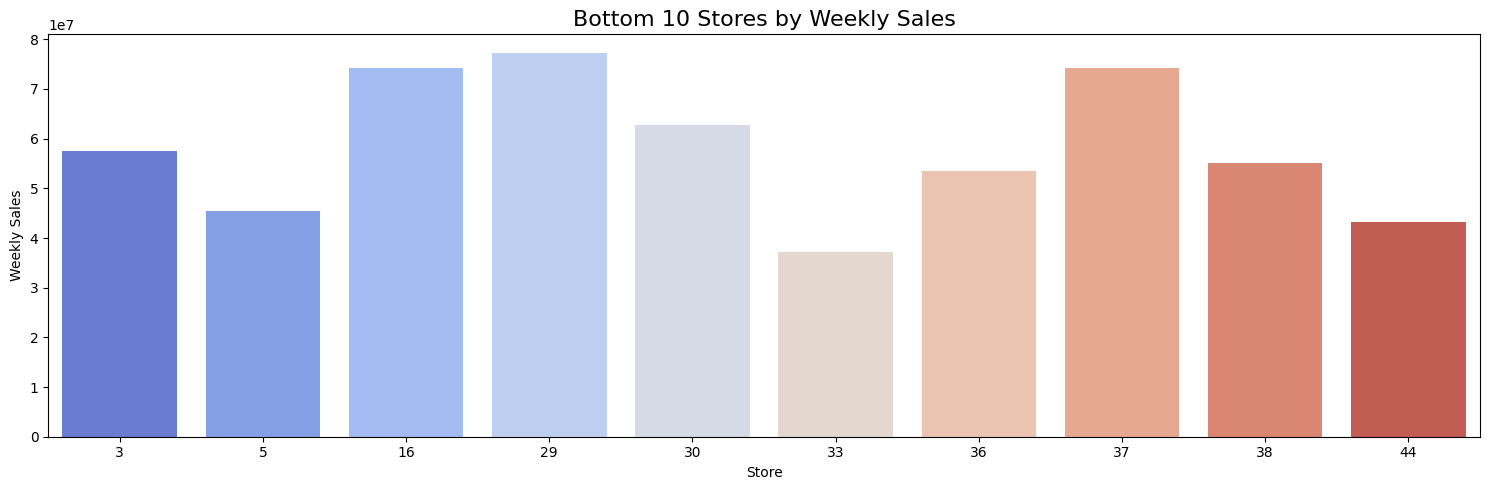

In [18]:
plt.figure(figsize=(15, 5))

sns.barplot(
    x='Store',
    y='Weekly_Sales',
    data=bottom_10_Sale_Store,
    palette='coolwarm'
)

plt.title('Bottom 10 Stores by Weekly Sales', fontsize=16)
plt.xlabel('Store')
plt.ylabel('Weekly Sales')

plt.tight_layout()
plt.show()


In [19]:
# Creating the dataframe which is having top 10 stores that can have highest weekly sales
top_10_Sale_Store = df_store_sales.sort_values(by='Weekly_Sales',ascending=False).head(10)
# Looking the dataframe
top_10_Sale_Store

,Store,Weekly_Sales
19,20,2.990663e+08
3,4,2.973575e+08
13,14,2.870091e+08
12,13,2.845247e+08
1,2,2.741628e+08
9,10,2.692807e+08
26,27,2.534795e+08
5,6,2.237489e+08
0,1,2.224028e+08
38,39,2.074455e+08


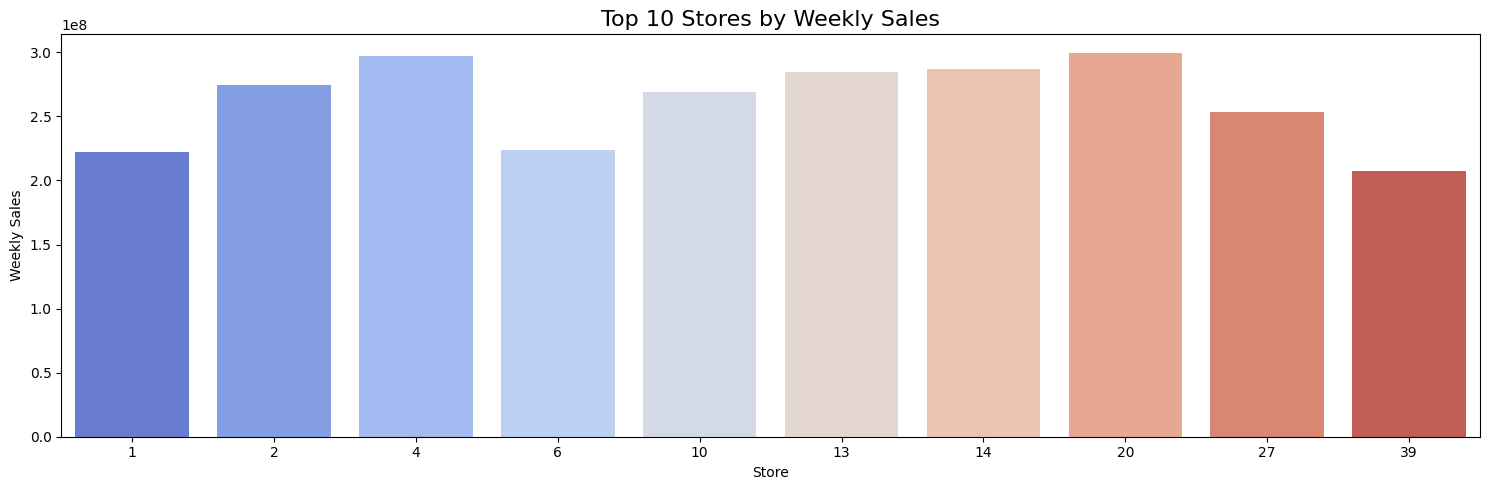

In [20]:
plt.figure(figsize=(15, 5))

sns.barplot(
    x='Store',
    y='Weekly_Sales',
    data=top_10_Sale_Store,
    palette='coolwarm'
)

plt.title('Top 10 Stores by Weekly Sales', fontsize=16)
plt.xlabel('Store')
plt.ylabel('Weekly Sales')

plt.tight_layout()
plt.show()


#Inference:
Within the bottom 10 performing stores, Stores 29, 16, and 37 record comparatively higher sales than the other low-performing outlets, while Stores 33 and 44 exhibit the weakest sales performance among the bottom 10 stores.

**Date vs Weekly Sales:**

In [21]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [22]:
# Converting the Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True, errors='coerce')

In [23]:
# Creating the dataframe by grouping the date and summing all the weekly sales for the particular 'Date'
df_date_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
df_date_sales=df_date_sales.sort_values(by='Date',ascending=True) # Sorting the values in the dataframe to ascending
df_date_sales.head(5) # Looking at first five data points

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [24]:
df_date_sales.shape

(143, 2)

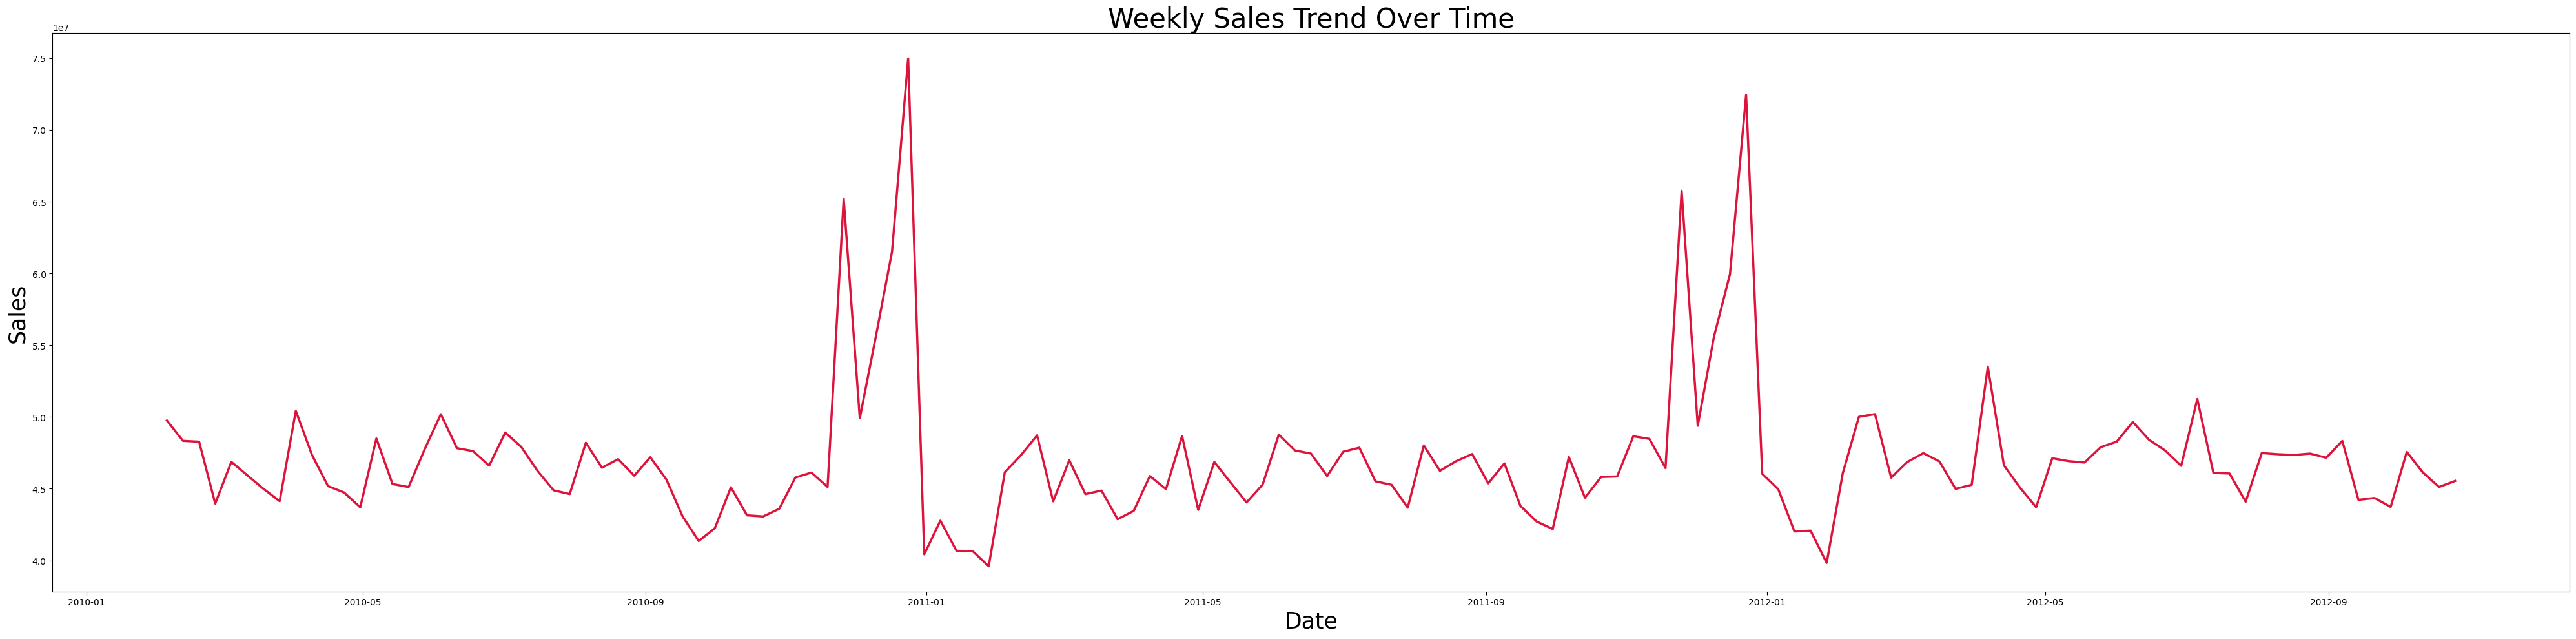

In [25]:
# Plotting the line chart to analyze the trend of weekly sales over time
plt.figure(figsize=(40, 10))  # Setting the figure size for better visibility

sns.lineplot(
    x='Date',
    y='Weekly_Sales',
    data=df_date_sales,
    color='crimson',      # Try: 'crimson', 'royalblue', 'seagreen', 'darkorange'
    linewidth=2.5
)

plt.title('Weekly Sales Trend Over Time', fontsize=30)
plt.xlabel('Date', fontsize=25)
plt.ylabel('Sales', fontsize=25)

plt.tight_layout()
plt.show()


#Inference:
Weekly sales remain relatively consolidated during most periods; however, certain quarters exhibit noticeable spikes. To identify these high-performing periods, sales are aggregated and analyzed on a quarterly basis.

In [26]:
# Categorizing weekly sales into quarterly periods for seasonal analysis
df['Quarters'] = df['Date'].dt.to_period("Q")

# Creating a new DataFrame by grouping weekly sales by quarters and calculating total sales per quarter
df_quarter_sales = df.groupby('Quarters')['Weekly_Sales'].sum().reset_index()

# Displaying quarterly aggregated sales data
df_quarter_sales

,Quarters,Weekly_Sales
0,2010Q1,3.722528e+08
1,2010Q2,6.103695e+08
2,2010Q3,5.974881e+08
3,2010Q4,7.018634e+08
4,2011Q1,5.293917e+08
5,2011Q2,5.979481e+08
6,2011Q3,6.393585e+08
7,2011Q4,6.759581e+08
8,2012Q1,5.924677e+08
9,2012Q2,6.182977e+08


<Axes: xlabel='Quarters', ylabel='Weekly_Sales'>

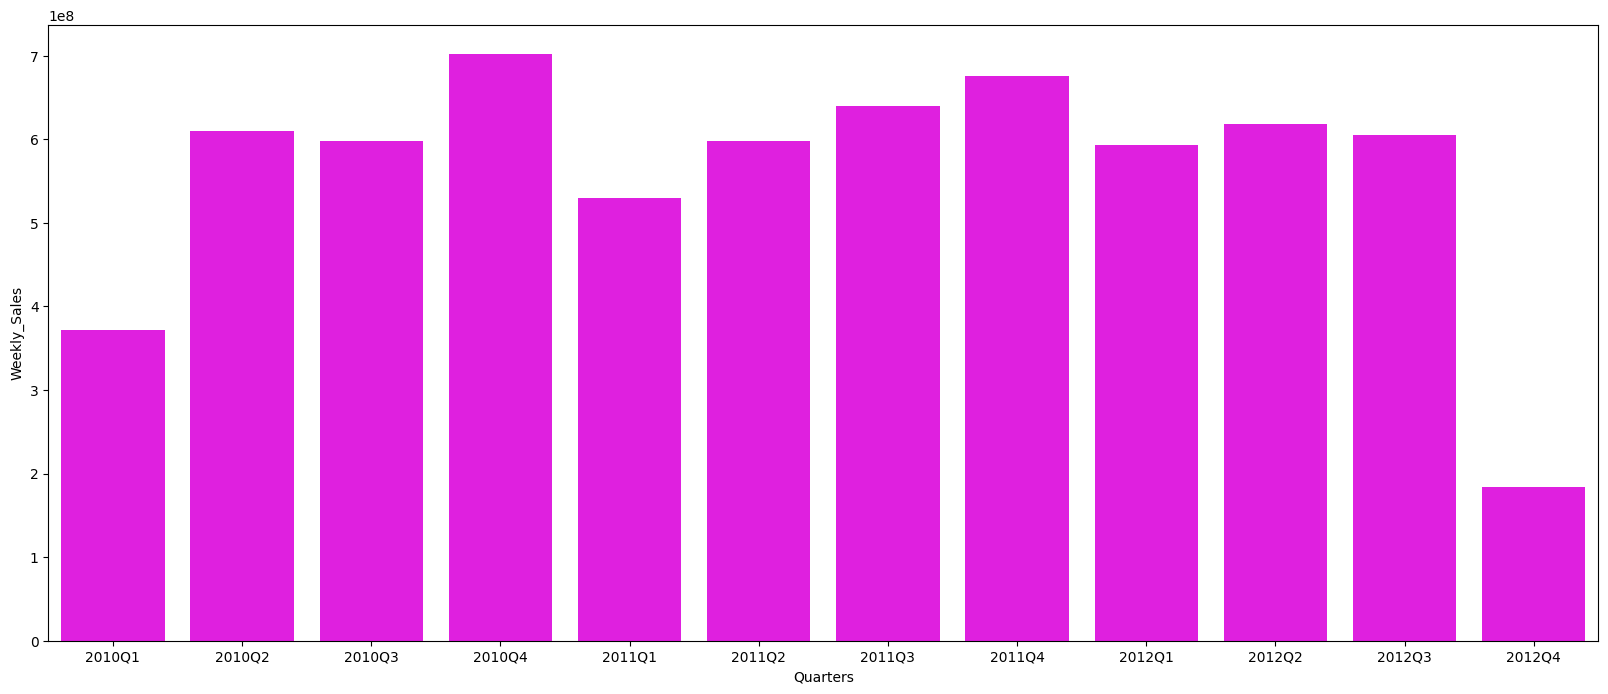

In [27]:
plt.figure(figsize=(20,8))
sns.barplot(x='Quarters', y='Weekly_Sales', data=df_quarter_sales, color='magenta')

#Inference:
In 2010, the second and fourth quarters (Q2 and Q4) recorded strong sales performance.

This positive trend continued in 2011, with Q4 reaching peak sales across the observed period.

However, in 2012, overall performance showed disruption, where Q2 maintained relatively high sales, while Q4 experienced a significant decline, marking the weakest fourth-quarter performance among the three years.

#Sales v/s Holidays

In [28]:
df['Holiday_Flag'].value_counts() # Checking the diffirent levels in Holiday column
# Creating a new datafram that contains holiday and weekly sales summation
df_Hf_Sales = df.groupby('Holiday_Flag')['Weekly_Sales'].sum().reset_index()
df_Hf_Sales# Checking The Df

,Holiday_Flag,Weekly_Sales
0,0,6.220935e+09
1,1,5.038284e+08


<Axes: xlabel='Holiday_Flag', ylabel='Weekly_Sales'>

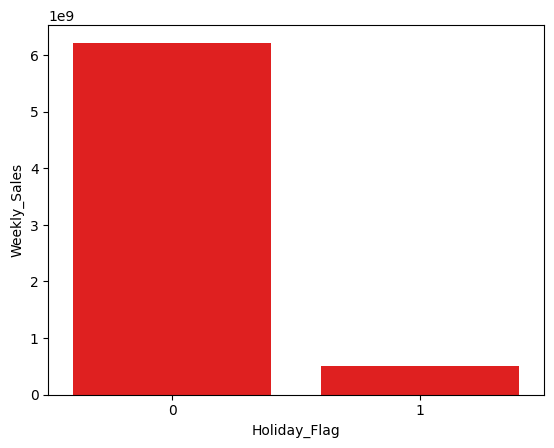

In [29]:
sns.barplot(x='Holiday_Flag',y='Weekly_Sales',data=df_Hf_Sales,color='red') # Plotting the distribution

#Inference:
Weekly sales are generally higher on normal (non-holiday) days compared to holiday periods. This is a common trend, as customer purchasing activity tends to be lower during holidays than on regular working days.

#Temperature v/s sales

In [30]:
df['Temperature'].min() # finding the lower band of Tempeture

6.240000000000002

In [31]:
df['Temperature'].max()

100.14

In [32]:
bins = [0,25,50,75,100] # Creating bins to sort the tempeture values
labels = ['0-25','26-50','51-75','76-100'] # Labels
df['Temp_Category']= pd.cut(df['Temperature'],bins=bins,labels=labels) # Inserting the temp values into the new column
df['Temp_Category'].value_counts() # Checking the diffirent columns in the temp category column

,count
Temp_Category,
51-75,2982
26-50,1631
76-100,1596
0-25,224


In [33]:
# finding sales pattren during these temp levels
df_temp_sales = df.groupby('Temp_Category')['Weekly_Sales'].sum().reset_index()

<Axes: xlabel='Temp_Category', ylabel='Weekly_Sales'>

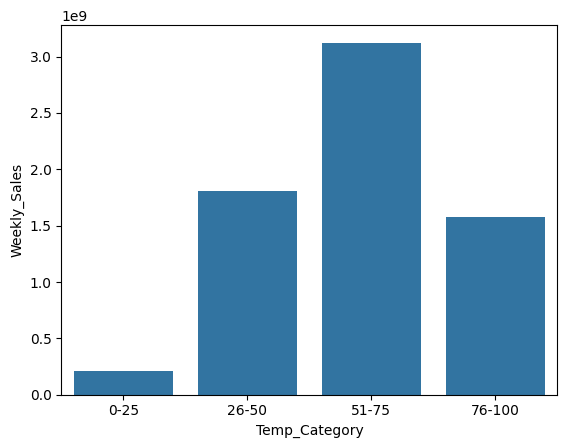

In [34]:
# Plotting the weekly sales distribution on barplot
sns.barplot(x='Temp_Category',y='Weekly_Sales',data=df_temp_sales)

#Inference:
Stores perform well in moderate temp that is 26-50
Sales went peaks in Moderate to High temp that is 51-75
Sales went down in Very High and Low temp that is 0-25 & 76-100

#Fuel_Price V/s Sales

In [35]:
df['Fuel_Price'].max() # Checking the Upper price band for fuel

4.468

In [36]:
df['Fuel_Price'].min() # Checking the lower price band for fuel

2.472

In [37]:
bins1 = [2,2.5,3,3.5,4,4.5] # Creating bins and labels to categorize the fuel prices
labels1 = ['2-2.5','2.6-3','3.1-3.5','3.6-4','4.1-4.5']
df['Fuel_Price_Cat']= pd.cut(df['Fuel_Price'],bins=bins1,labels=labels1) # creating new dataframe Fuel price category
df['Fuel_Price_Cat'].value_counts() # Checking the different levels in the fuel price category

,count
Fuel_Price_Cat,
3.6-4,2625
2.6-3,1872
3.1-3.5,1533
4.1-4.5,404
2-2.5,1


In [38]:
df_Fuel_Price_Sales = df.groupby('Fuel_Price_Cat')['Weekly_Sales'].sum().reset_index()
df_Fuel_Price_Sales

,Fuel_Price_Cat,Weekly_Sales
0,2-2.5,4.702810e+05
1,2.6-3,1.945889e+09
2,3.1-3.5,1.620472e+09
3,3.6-4,2.738130e+09
4,4.1-4.5,4.198009e+08


<Axes: xlabel='Weekly_Sales', ylabel='Fuel_Price_Cat'>

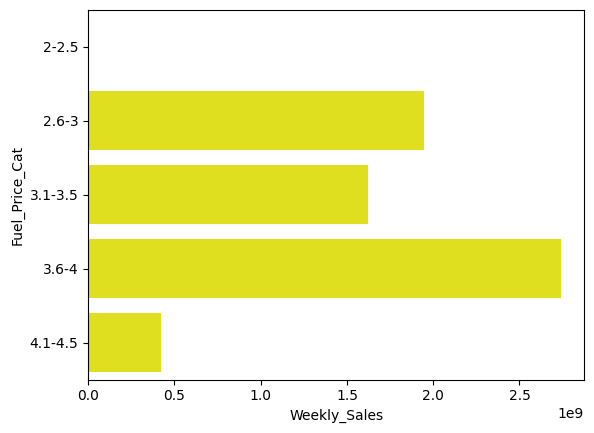

In [39]:
sns.barplot(y='Fuel_Price_Cat',x='Weekly_Sales',data=df_Fuel_Price_Sales,color='yellow')

#Inference

When fuel prices are at moderate levels, store performance and weekly sales are also moderately high.

As fuel prices rise above the moderate level (around 3.5), sales initially increase, possibly due to inflation concerns and customers stocking up on groceries in anticipation of further price hikes.

However, when fuel prices increase further to very high levels, purchasing power declines, leading to a drop in weekly sales as the overall cost of living and goods increases.

#CPI v/s Sales

In [40]:
# Checking the upper band of inflation
df['CPI'].max()

227.2328068

In [41]:
# Checking the lower band of inflation
df['CPI'].min()

126.064

In [42]:
bins2=[125,155,185,215,245] # Creating bins and labels for categorization of inflation rate
labels2=['125-155','156-185','186-215','216-245',]

In [43]:
df['CPI_cat']= pd.cut(df['CPI'],bins=bins2,labels=labels2)
df.tail()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Quarters,Temp_Category,Fuel_Price_Cat,CPI_cat
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012Q3,51-75,3.6-4,186-215
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,2012Q4,51-75,3.6-4,186-215
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,2012Q4,51-75,3.6-4,186-215
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012Q4,51-75,3.6-4,186-215
6434,45,2012-10-26,760281.43,0,58.85,3.882,192.308899,8.667,2012Q4,51-75,3.6-4,186-215


In [44]:
df['CPI_cat'].value_counts() # Checking diffirent levels in inflation

,count
CPI_cat,
125-155,3146
186-215,2010
216-245,1159
156-185,120


In [45]:
df_Cpi_Sales = df.groupby('CPI_cat')['Weekly_Sales'].sum().reset_index()
df_Cpi_Sales

,CPI_cat,Weekly_Sales
0,125-155,3.400064e+09
1,156-185,1.738193e+08
2,186-215,2.028806e+09
3,216-245,1.122074e+09


<Axes: xlabel='CPI_cat', ylabel='Weekly_Sales'>

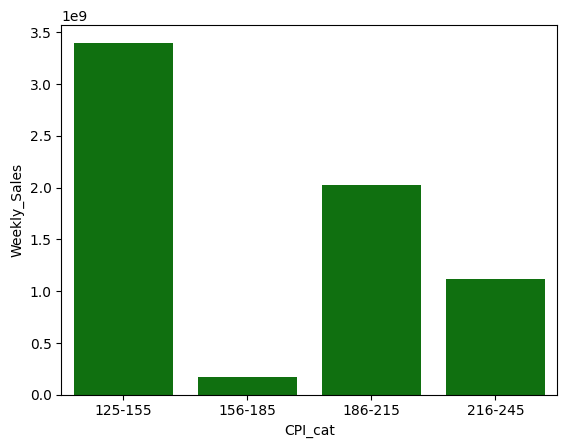

In [46]:
sns.barplot(x='CPI_cat',y='Weekly_Sales',data=df_Cpi_Sales,color='green')

#Inference:
When inflation levels are low, store performance and weekly sales remain high, indicating stable consumer purchasing power.

During the initial phase of rising inflation, sales decline significantly, as customers become cautious with spending.

As inflation increases further, some consumers increase purchases due to fear of future price hikes, leading to a temporary rise in sales.

However, when inflation reaches peak levels, overall purchasing power decreases, resulting in a decline in weekly sales.

#Unemployment V/s Sales

In [47]:
df['Unemployment'].min() # Cheking the lower band of unemp rate

4.2945

In [48]:
df['Unemployment'].max() # Cheking the Upper band of unemp rate

11.218499999999999

In [49]:
bins3=[4,6,8,10,12] # Creating the bins and labels to store the values
labels3=['4-6','6.1-8','8.1-10','10.1-12']

In [50]:
df['Unemployment_Rate_Cat']= pd.cut(df['Unemployment'],bins=bins3,labels=labels3) # creating the new column in the dataframe
df['Unemployment_Rate_Cat'].value_counts() #Checking the diffirent levels in the UnEmp Column

,count
Unemployment_Rate_Cat,
6.1-8,2795
8.1-10,2389
10.1-12,629
4-6,622


In [51]:
df_Un_Emp_Sales = df.groupby('Unemployment_Rate_Cat')['Weekly_Sales'].sum().reset_index() # Creating separte dataframe for the sales and UnEmp rate

<Axes: xlabel='Unemployment_Rate_Cat', ylabel='Weekly_Sales'>

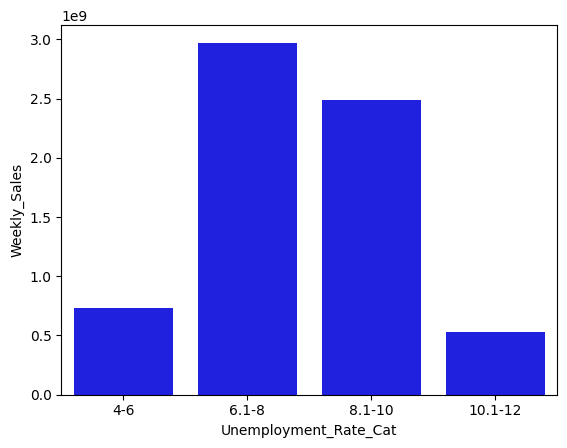

In [52]:
sns.barplot(x='Unemployment_Rate_Cat',y='Weekly_Sales',data=df_Un_Emp_Sales,color='blue')

When the Unemployment rate is between the 6 to 10 the stores are performing well
But whenever the Unemployment rate is increasing the sales went down

#Statistical Analysis

In [53]:
from sklearn.preprocessing import LabelEncoder
Le = LabelEncoder()

In [54]:
df_Encode = df[['Quarters','Temp_Category','Fuel_Price_Cat','CPI_cat','Unemployment_Rate_Cat']].copy()

In [55]:
df_Encode['Quarters']=Le.fit_transform(df['Quarters'])
df_Encode['Temp_Category']=Le.fit_transform(df['Temp_Category'])
df_Encode['Fuel_Price_Cat']=Le.fit_transform(df['Fuel_Price_Cat'])
df_Encode['CPI_cat']=Le.fit_transform(df['CPI_cat'])
df_Encode['Unemployment_Rate_Cat']=Le.fit_transform(df['Unemployment_Rate_Cat'])
df_Encode['Weekly_Sales']=Le.fit_transform(df['Weekly_Sales'])

In [56]:
# Dropping Repating columns
#df_Encode.drop('Date',axis=1,inplace=True)
#df_Encode.drop('Temperature',axis=1,inplace=True)
#df_Encode.drop('Fuel_Price',axis=1,inplace=True)
#df_Encode.drop('CPI',axis=1,inplace=True)
#df_Encode.drop('Unemployment',axis=1,inplace=True)

In [57]:
corr_df = df_Encode.corr()

<Axes: >

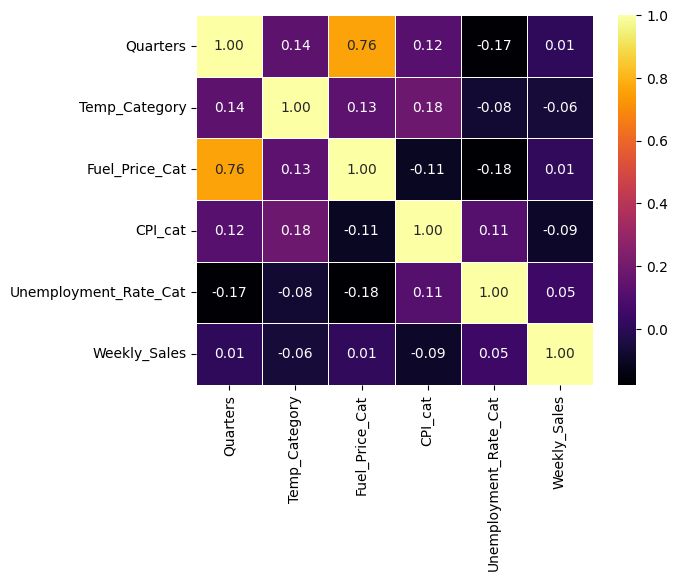

In [58]:
sns.heatmap(corr_df,annot=True,cmap='inferno',fmt=".2f",linewidths=.5)

**Inference:**

Quarters and Fuel Price having high correlation
Because the fuel prices are also depend on the seasonal changes

#Questions Part

1. You are provided with the weekly sales data for their various outlets. Use statistical analysis, EDA, outlier analysis, and handle the missing values to come up with various insights that can give them a clear perspective on the following

a. If the weekly sales are affected by the unemployment rate, if yes - which stores are suffering the most?

<Axes: xlabel='Unemployment_Rate_Cat', ylabel='Weekly_Sales'>

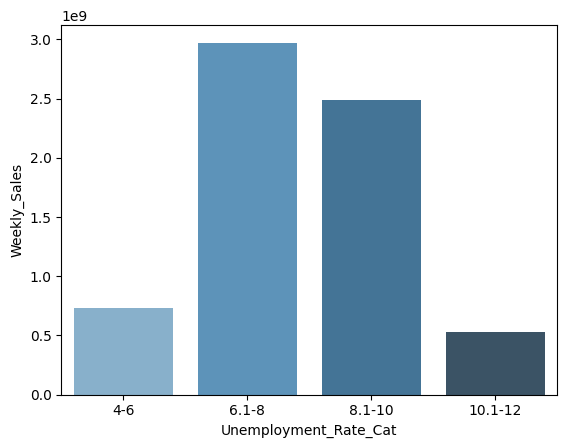

In [59]:
sns.barplot(x='Unemployment_Rate_Cat',y='Weekly_Sales',data=df_Un_Emp_Sales, palette='Blues_d')

**Inference:**

we can see that where the Unemployment Rate is too low and too high the sales are affected compared to moderate Unemployment Rate.
So we need to find out the store which are suffering the most in this Unemployment rate category.

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Store                  6435 non-null   int64         
 1   Date                   6435 non-null   datetime64[ns]
 2   Weekly_Sales           6435 non-null   float64       
 3   Holiday_Flag           6435 non-null   int64         
 4   Temperature            6435 non-null   float64       
 5   Fuel_Price             6435 non-null   float64       
 6   CPI                    6435 non-null   float64       
 7   Unemployment           6435 non-null   float64       
 8   Quarters               6435 non-null   period[Q-DEC] 
 9   Temp_Category          6433 non-null   category      
 10  Fuel_Price_Cat         6435 non-null   category      
 11  CPI_cat                6435 non-null   category      
 12  Unemployment_Rate_Cat  6435 non-null   category      
dtypes: 

In [61]:
# Since the dataset contains categorical columns, label encoding is applied for easier filtering and analysis.
# Importing LabelEncoder for encoding categorical features
from sklearn.preprocessing import LabelEncoder

In [62]:
label_encoder=LabelEncoder() # assigening it to a variable
df['Unemployment_Rate_Cat'] = label_encoder.fit_transform(df['Unemployment_Rate_Cat']) # Encoding the data
df['Unemployment_Rate_Cat'].value_counts()

,count
Unemployment_Rate_Cat,
2,2795
3,2389
0,629
1,622


In [63]:
filtered_df = df[df['Unemployment_Rate_Cat'].isin([1, 0])]

In [64]:
sales_unemp_store= filtered_df.groupby('Store')['Weekly_Sales'].sum().reset_index()
sales_unemp_store

,Store,Weekly_Sales
0,4,1.782381e+08
1,5,1.416884e+07
2,6,4.684711e+07
3,8,3.923392e+07
4,9,2.397403e+07
5,12,1.442872e+08
6,13,6.152466e+07
7,16,2.016068e+06
8,17,1.623276e+07
9,23,1.987367e+08


In [65]:
# Among the 17 stores affected by unemployment, the top 5 most impacted stores are selected
# based on the lowest weekly sales for clearer interpretation.

print('Most Affected Stores by Unemployment Rate (Top 5):')

sales_unemp_store.sort_values(by='Weekly_Sales', ascending=True).head()


Most Affected Stores by Unemployment Rate (Top 5):


,Store,Weekly_Sales
7,16,2016067.98
12,33,2299155.24
1,5,14168838.13
17,44,14187373.72
8,17,16232762.69


b. If the weekly sales show a seasonal trend, when and what could be the reason?

In [66]:
# Weekly Sales
df_stores_sales =df.groupby('Date')['Weekly_Sales'].sum().reset_index()
df_stores_sales.set_index('Date',inplace=True) # Setting the Date column as an Index
from statsmodels.tsa.seasonal import seasonal_decompose
sales_decomposition=seasonal_decompose(df_stores_sales['Weekly_Sales'],period=13)

Figure(640x480)


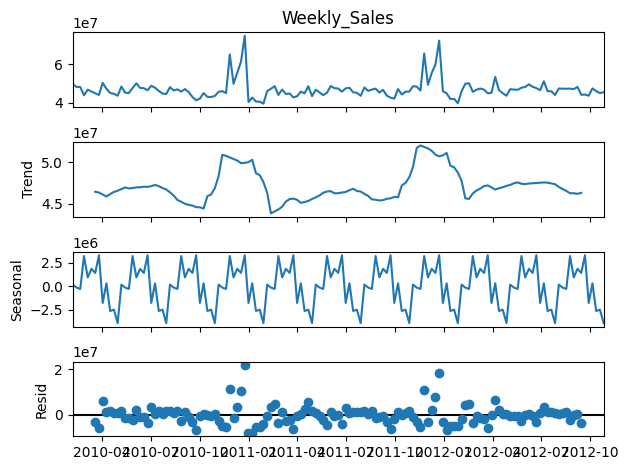

In [67]:
print(sales_decomposition.plot())

In [68]:
# Temperature
df_Temperature =df.groupby('Date')['Temperature'].sum().reset_index()
df_Temperature.set_index('Date',inplace=True) # Setting the Date column as an Index
Temperature_decomposition=seasonal_decompose(df_Temperature['Temperature'],period=13)

Figure(640x480)


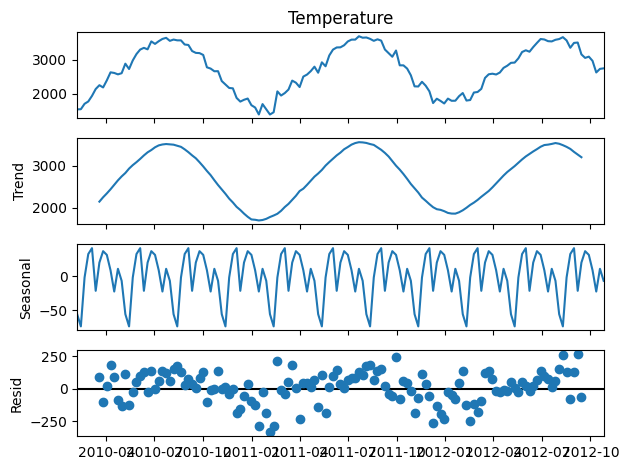

In [69]:
print(Temperature_decomposition.plot())

**Inference:**


* Seasonal sales spikes observed from Sep–Jan in 2010–11 and 2011–12

* Weaker seasonal effect in 2012

* Winter seasonality suggests possible temperature impact, validated separately
* Regarding the Temperature data, a seasonal downward trend is observed starting from September 2010 until January 2011. Subsequently, there's a gradual increase. However, from September 2011, temperatures start to decline again.

* In the Weekly Sales Data, there is a noticeable increase in sales starting from September 2010, followed by a seasonal upward trend until January 2011. Afterward, the sales stabilize, eventually transitioning to a downward trend. This pattern is repeated from September 2011 to January 2012.

* In summary, there appears to be an inverse relationship between Temperature and Weekly Sales. When temperatures decrease, weekly sales tend to rise, and vice versa. This inverse correlation is evident from September 2011 to January 2012, as well as from September 2011 to January 2012.

c. Does temperature affect the weekly sales in any manner?

<Axes: >

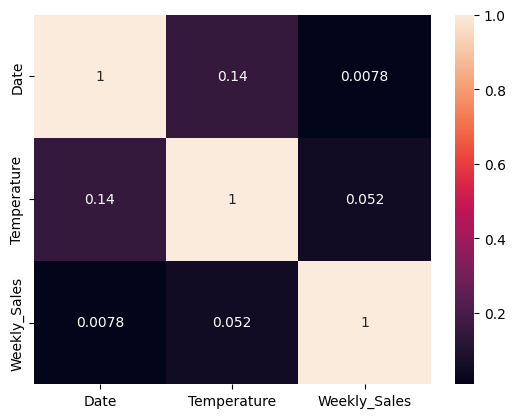

In [70]:
df_temp_sales = df.groupby(['Date','Temperature'])['Weekly_Sales'].sum().reset_index()
df_temp_sales_correlation =df_temp_sales.corr()
sns.heatmap(df_temp_sales_correlation,annot=True)

**Inference:**
Yes there is a Nagative correlation and the Temperature is affecting the Weekly Sales

**d. How is the Consumer Price index affecting the weekly sales of various stores?**

<Axes: >

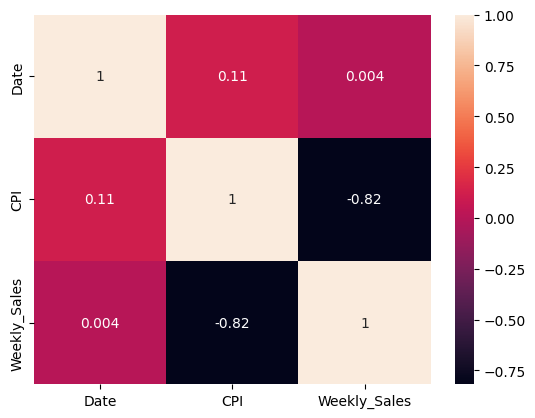

In [71]:
df_cpi_sales = df.groupby(['Date','CPI'])['Weekly_Sales'].sum().reset_index()
df_cpi_sales_correlation =df_cpi_sales.corr()
sns.heatmap(df_cpi_sales_correlation,annot=True)

**Inference:** Yes there is a Negative correlation and the CPI is affecting the Weekly Sales as we can see that in below graph as well. when the CPI increasing the sales are down

<Axes: xlabel='CPI_cat', ylabel='Weekly_Sales'>

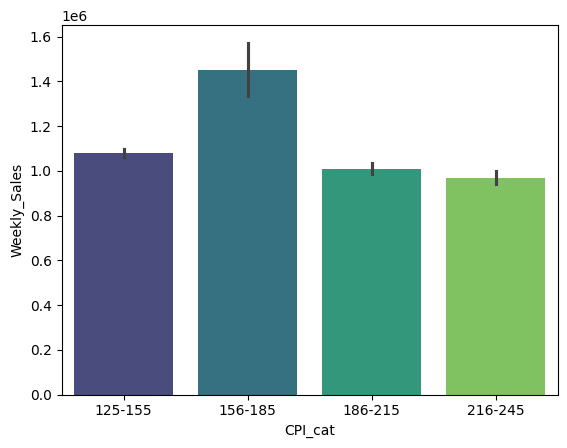

In [72]:
sns.barplot(x=df['CPI_cat'],y=df['Weekly_Sales'], palette='viridis')

**e. Top performing stores according to the historical data.**

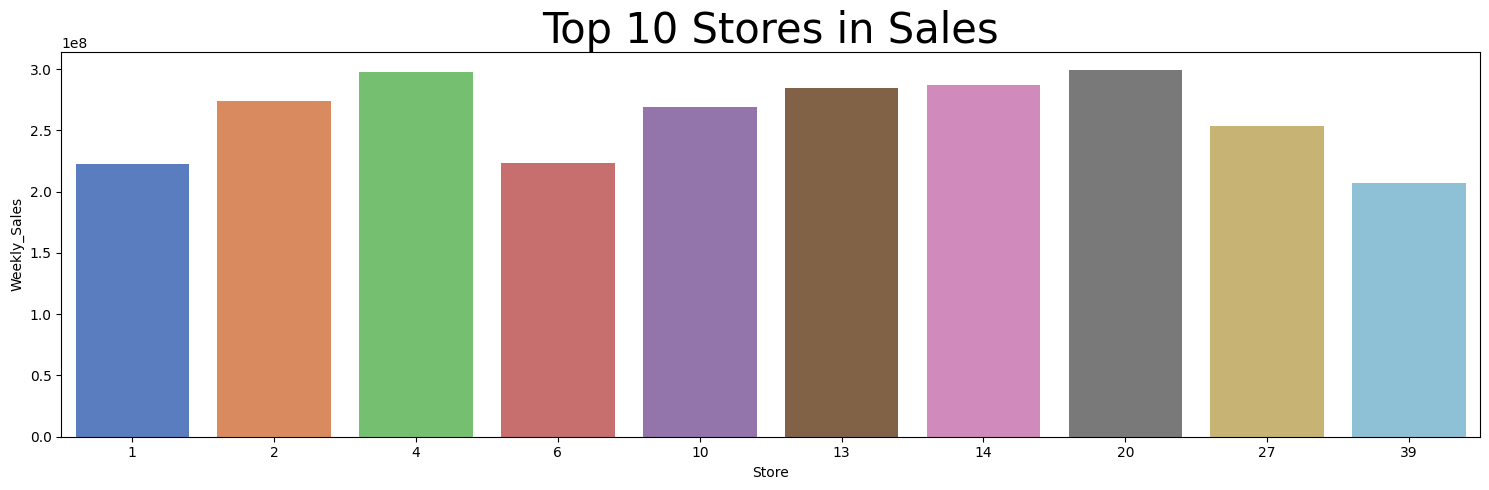

In [73]:
# plotting the top 10 stores
plt.figure(figsize=(15,5))
sns.barplot(x='Store',y='Weekly_Sales',data=top_10_Sale_Store, palette='muted')
plt.title('Top 10 Stores in Sales',fontsize=30)
plt.xlabel('Store')
plt.ylabel('Weekly_Sales')
plt.tight_layout()
plt.show()

**Inference:**
* The Stores 4,20,14 is having the highest sales in top 10 stores segment
* The Stores 6,39 is having the Lowest sales in top 10 stores segment

**f. The worst performing store, and how significant is the difference between the highest and lowest performing stores.**

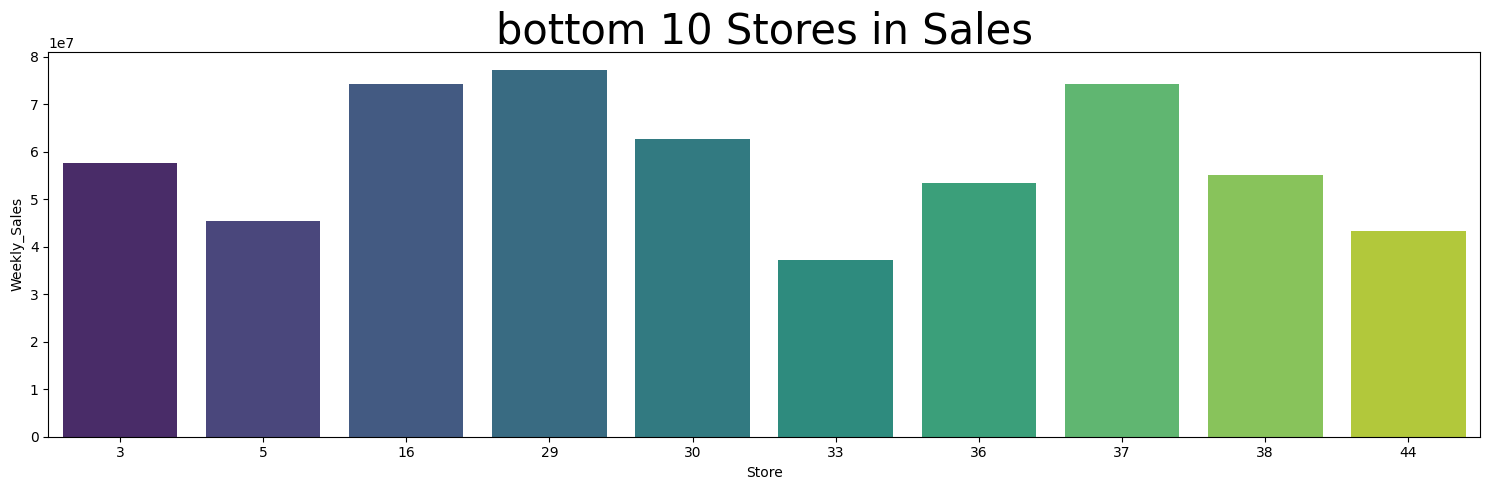

In [74]:
# plotting the Bottom 10 stores
plt.figure(figsize=(15,5)) # setting the frame to plot the store sales
sns.barplot(x='Store',y='Weekly_Sales',data=bottom_10_Sale_Store,palette='viridis') # creating the barplot
plt.title('bottom 10 Stores in Sales',fontsize=30) # Set the titles
plt.xlabel('Store') # asigening the 'X' label as "Store"
plt.ylabel('Weekly_Sales') # asigening the 'Y' label as "Weekly sales"
plt.tight_layout() # this can help the barplot to set correctly in the frame
plt.show()

**Infernece:**
* The Stores 29,16,37 is having the highest sales in Bottom 10 stores segment
* The Stores 33,44 is having the highest sales in Bottom 10 stores segment

**Finding The significance difference**

for getting the signficant difference between top and bottom performing stores
we will use t-test weather it has a significant difference or not

In [75]:
from scipy.stats import ttest_ind # Importing the ttest_ind.. this helps us to compare mean between the two indipendent groups
top_sales = top_10_Sale_Store['Weekly_Sales']
worst_sales = bottom_10_Sale_Store['Weekly_Sales']
t_statistic, p_value = ttest_ind(top_sales, worst_sales)

In [76]:
# Interpret results
if p_value < 0.05:
    print("There is a significant difference between top-performing and worst-performing stores.")
    print(f"P-value: {p_value}")
else:
    print("There is no significant difference between top-performing and worst-performing stores.")
    print(f"P-value: {p_value}")

There is a significant difference between top-performing and worst-performing stores.
P-value: 7.079291347377579e-13


In [77]:
mean_difference = top_sales.mean() - worst_sales.mean()
print("Significant Mean difference value between groups:", mean_difference)

Significant Mean difference value between groups: 203807667.66124997


#2. Use predictive modeling techniques to forecast the sales for each store for the next 12 weeks.

In [78]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Quarters,Temp_Category,Fuel_Price_Cat,CPI_cat,Unemployment_Rate_Cat
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010Q1,26-50,2.6-3,186-215,3
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010Q1,26-50,2.6-3,186-215,3
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010Q1,26-50,2.6-3,186-215,3
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010Q1,26-50,2.6-3,186-215,3
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010Q1,26-50,2.6-3,186-215,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012Q3,51-75,3.6-4,186-215,3
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,2012Q4,51-75,3.6-4,186-215,3
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,2012Q4,51-75,3.6-4,186-215,3
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012Q4,51-75,3.6-4,186-215,3


In [79]:
# Excluding all the varibales.. and considering the date and sales data for model building
df_stores_sales =df.groupby('Date')['Weekly_Sales'].sum().reset_index()

In [80]:
df_stores_sales.set_index('Date',inplace=True) # Setting the Date column as an Index

In [81]:
from statsmodels.tsa.stattools import adfuller # importing the adfuller for check the data stationarity

# check for stationarity
def adf_test(series, title=''): # creating a function

    print('Augmented Dickey-Fuller Test: {}'.format(title))
    result = adfuller(series,autolag='AIC')
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out['critical value ({})'.format(key)]=val

    # .to_string() removes the line "dtype: float64"
    print(out.to_string())

    if result[1] <= 0.05:

        print("Rejects the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary.")
adf_test(df_stores_sales['Weekly_Sales'],title='ADF TEST')

Augmented Dickey-Fuller Test: ADF TEST
ADF test statistic     -6.117153e+00
p-value                 9.036826e-08
# lags used             4.000000e+00
# observations          1.380000e+02
critical value (1%)    -3.478648e+00
critical value (5%)    -2.882722e+00
critical value (10%)   -2.578065e+00
Rejects the null hypothesis
Data has no unit root and is stationary


In [82]:
# Importing the seasonal decompose for break down the components of the time series data
from statsmodels.tsa.seasonal import seasonal_decompose

Figure(640x480)


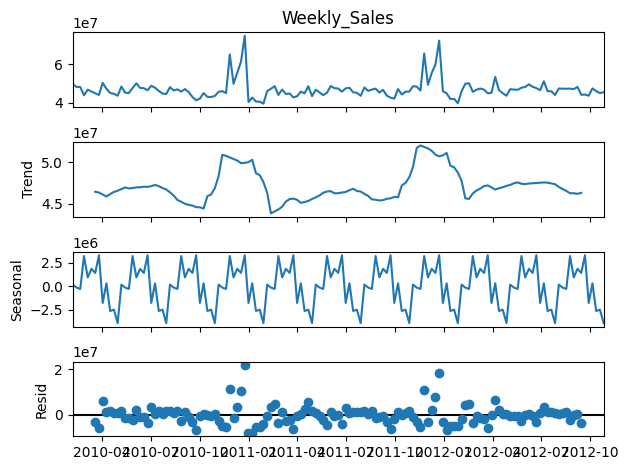

In [83]:
decomposition=seasonal_decompose(df_stores_sales['Weekly_Sales'],period=13)
print(decomposition.plot())

In [84]:
mean1=df_stores_sales.rolling(window=10).mean() # Creating the Rolling mean
std1=df_stores_sales.rolling(window=10).std() # Creating the Rolling standard deviation

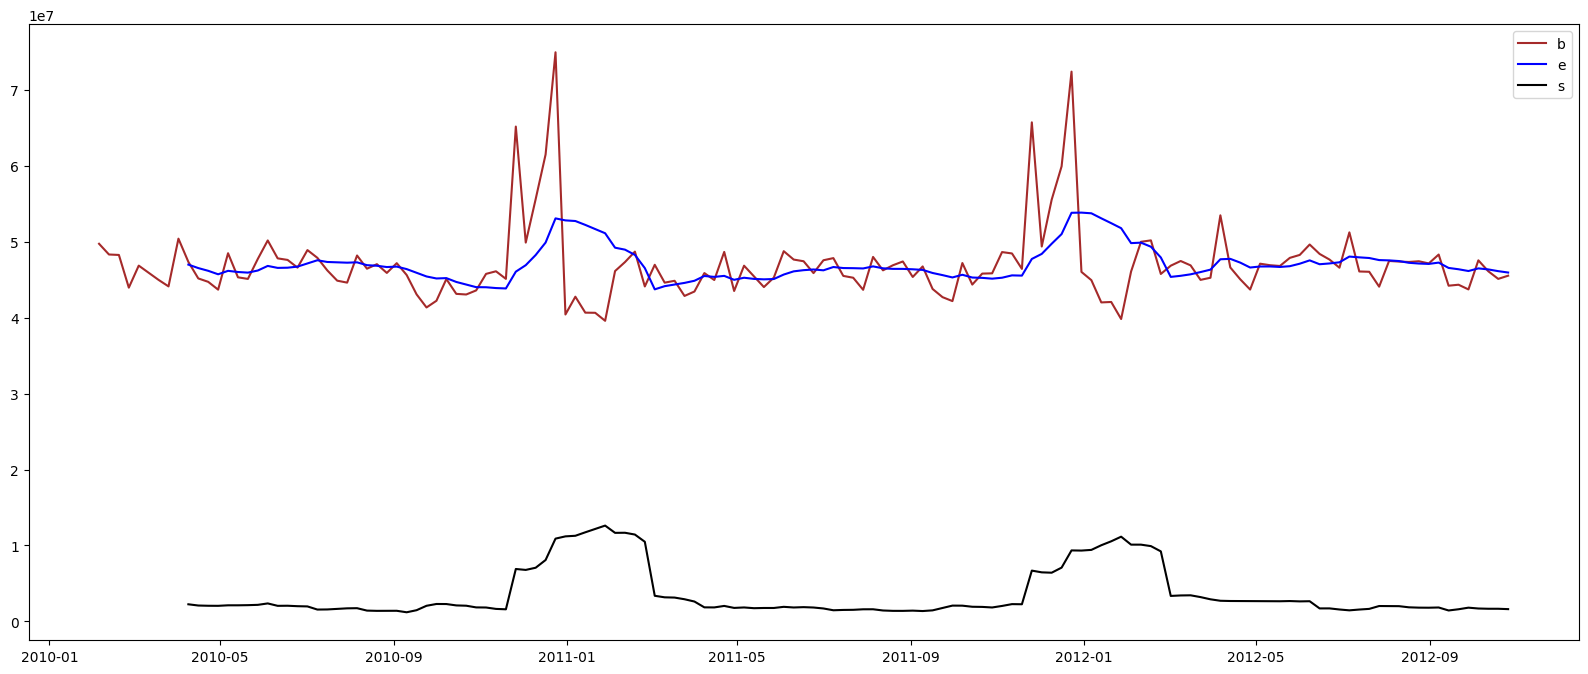

In [85]:
# plotting the rolling mean and standard deviation with respect to weekly sales
plt.figure(figsize=(20,8))
orig=plt.plot(df_stores_sales['Weekly_Sales'],color='brown',label='Original')
mean=plt.plot(mean1,color='blue',label='Rolling Mean')
std=plt.plot(std1,color='black',label='Rolling Std')
plt.legend('best')
plt.show(block=False)

**Inference:** Mean and sales are alomose close.. but the mean is not capturing the seasonal spikes

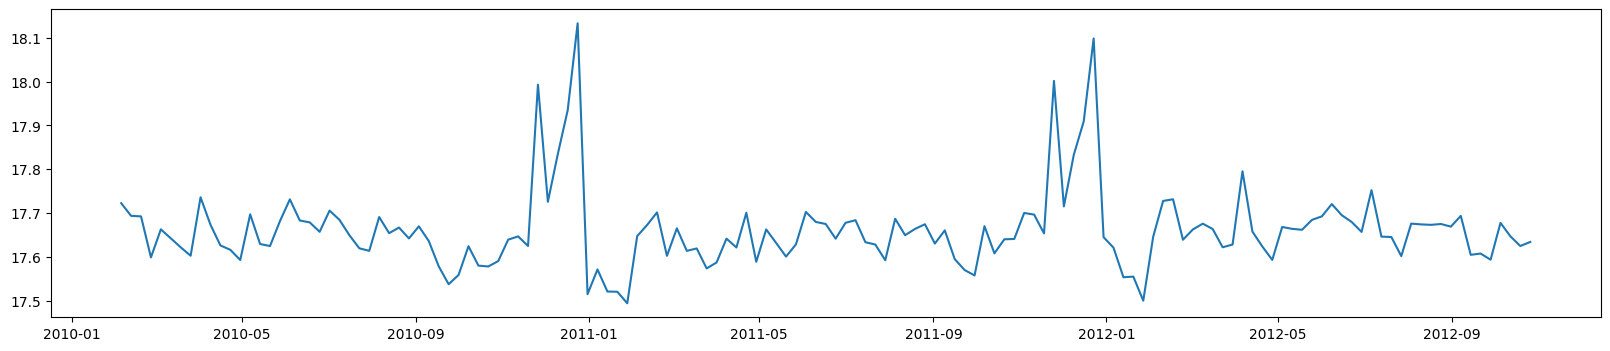

In [86]:
df_log = np.log(df_stores_sales)# applying log transformation to the data
plt.figure(figsize=(20,4))
plt.plot(df_log)

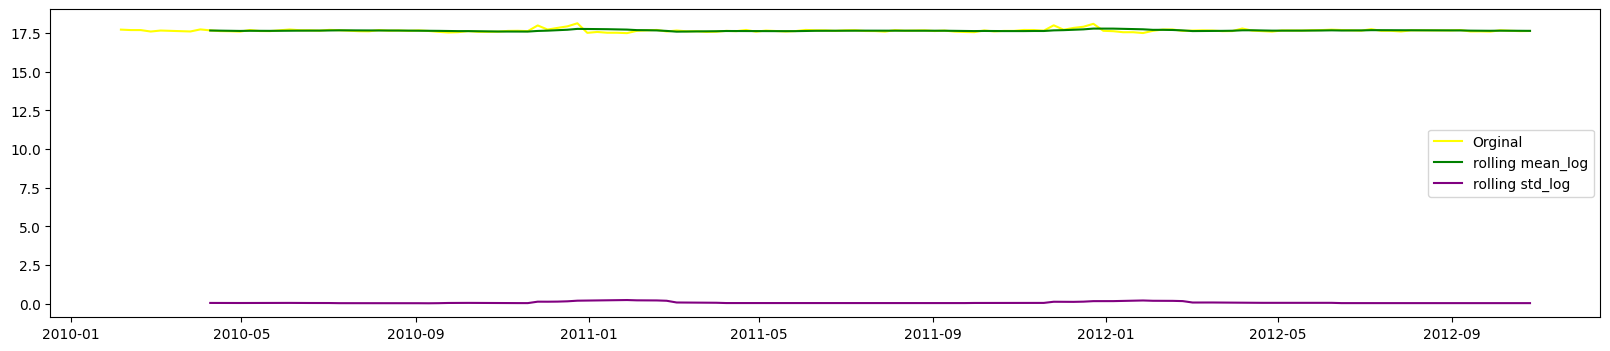

In [87]:
# After the log transformation to the data we are comparing the actual data with rolling mean and standard deviation are colse
mean_log = df_log.rolling(window = 10).mean()
std_log = df_log.rolling(window = 10).std()
plt.figure(figsize=(20,4))
plt.plot(df_log,color= 'yellow',label = 'Orginal')
plt.plot(mean_log, color = 'green', label = 'rolling mean_log')
plt.plot(std_log, color = 'purple', label = 'rolling std_log')
plt.legend(loc = 'best')
plt.show()

In [88]:
# subtracting the log data and mean log data,
# can help in stabilizing the variance of the data, which is a common requirement for many time series modeling techniques.
df_new = df_log - mean_log
df_new.head(20)

,Weekly_Sales
Date,
2010-02-05,NaN
2010-02-12,NaN
2010-02-19,NaN
2010-02-26,NaN
2010-03-05,NaN
2010-03-12,NaN
2010-03-19,NaN
2010-03-26,NaN
2010-04-02,NaN


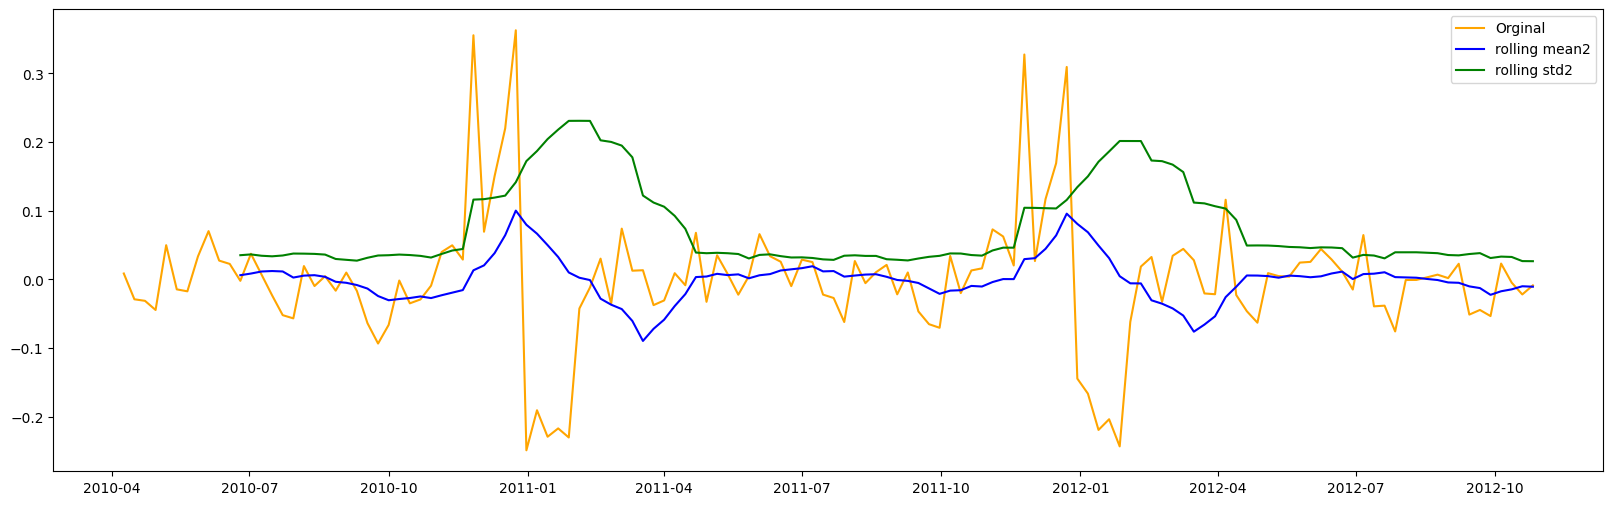

In [89]:
df_new.dropna(inplace = True) # dropping the nan values
# after the log transformation checking rolling stastics such as mean and standard deviation
mean2 = df_new.rolling(window = 12).mean()
std2 = df_new.rolling(window = 12).std()

plt.figure(figsize=(20,6))
plt.plot(df_new,color= 'orange',label = 'Orginal')
plt.plot(mean2, color = 'blue', label = 'rolling mean2')
plt.plot(std2, color = 'green', label = 'rolling std2')
plt.legend(loc = 'best')
plt.show()

In [90]:
adf_test(df_new['Weekly_Sales'],title='ADF TEST') # Checking the Data stationarity again after the log transformation

Augmented Dickey-Fuller Test: ADF TEST
ADF test statistic     -7.135358e+00
p-value                 3.432339e-10
# lags used             4.000000e+00
# observations          1.290000e+02
critical value (1%)    -3.482088e+00
critical value (5%)    -2.884219e+00
critical value (10%)   -2.578864e+00
Rejects the null hypothesis
Data has no unit root and is stationary


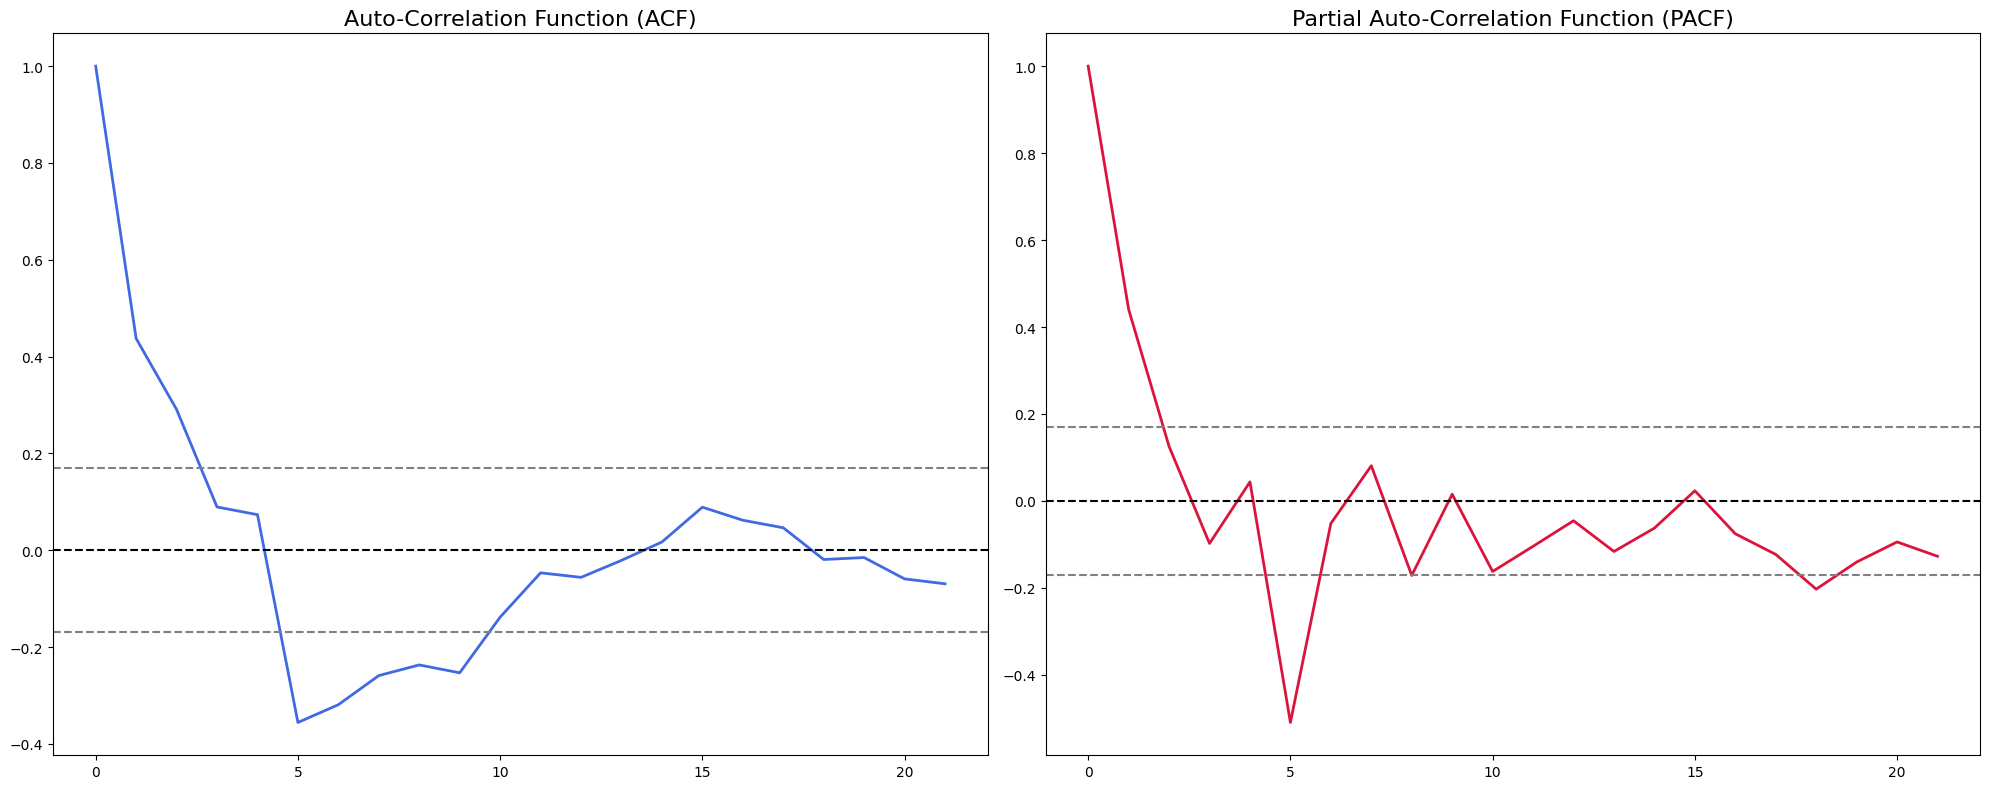

In [91]:
from statsmodels.tsa.stattools import acf, pacf
import numpy as np
import matplotlib.pyplot as plt

# Plotting the ACF and PACF to identify suitable values of p and q for the ARIMA model
lag_acf = acf(df_new)
lag_pacf = pacf(df_new)

plt.figure(figsize=(20, 8))

# Plot ACF
plt.subplot(121)
plt.plot(lag_acf, color='royalblue', linewidth=2)
plt.axhline(y=0, linestyle='--', color='black')
plt.axhline(y=-1.96/np.sqrt(len(df_new)), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(df_new)), linestyle='--', color='gray')
plt.title('Auto-Correlation Function (ACF)', fontsize=16)
plt.tight_layout()

# Plot PACF
plt.subplot(122)
plt.plot(lag_pacf, color='crimson', linewidth=2)
plt.axhline(y=0, linestyle='--', color='black')
plt.axhline(y=-1.96/np.sqrt(len(df_new)), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(df_new)), linestyle='--', color='gray')
plt.title('Partial Auto-Correlation Function (PACF)', fontsize=16)
plt.tight_layout()

plt.show()


we got out P value as 5 and q value as 3

In [92]:
# Buliding the ARIMA MODEL
from statsmodels.tsa.arima.model import ARIMA


model = ARIMA(df_new, order=(5, 1, 3))
arima_result = model.fit()

# Get predictions on historical data
predictions = arima_result.predict()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


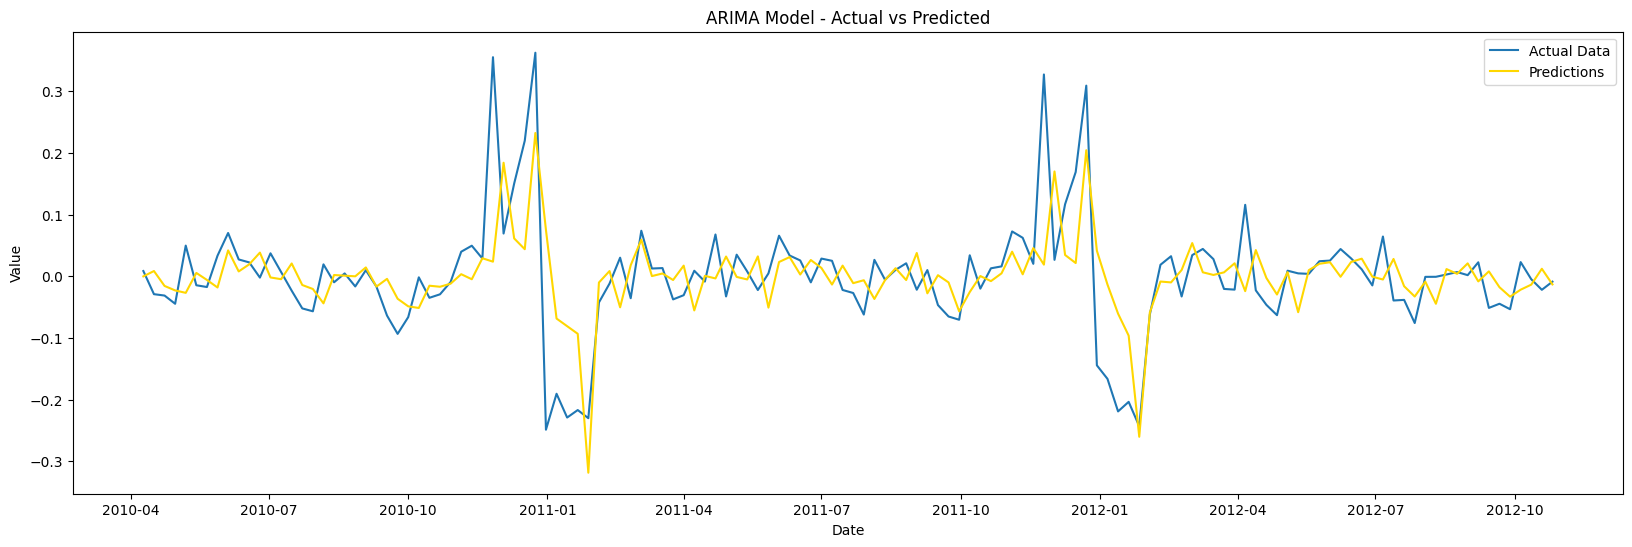

In [93]:
plt.figure(figsize=(20,6))
plt.plot(df_new, label='Actual Data')
plt.plot(predictions, color='gold', label='Predictions')
plt.title('ARIMA Model - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [94]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(df_new,predictions)
print(f'Mean Squared_Error{mse}')

Mean Squared_Error0.005746298003683677


In [95]:
rmse=np.sqrt(mse)
print(f'Root Mean Squared_Error{rmse}')

Root Mean Squared_Error0.07580434026943099


#Store Wise Predictions
**Store 2** Sales Forecast

In [96]:
# Creating a new data frame for store 1 sales forecast
store2_sales=df[df['Store']==2].groupby('Date')['Weekly_Sales'].sum().reset_index()

In [97]:
store2_sales.set_index('Date',inplace=True) # Setting the date column as an index

In [98]:
adf_test(store2_sales['Weekly_Sales'],title='ADF TEST')

Augmented Dickey-Fuller Test: ADF TEST
ADF test statistic       -3.873677
p-value                   0.002237
# lags used               6.000000
# observations          136.000000
critical value (1%)      -3.479372
critical value (5%)      -2.883037
critical value (10%)     -2.578234
Rejects the null hypothesis
Data has no unit root and is stationary


Figure(640x480)


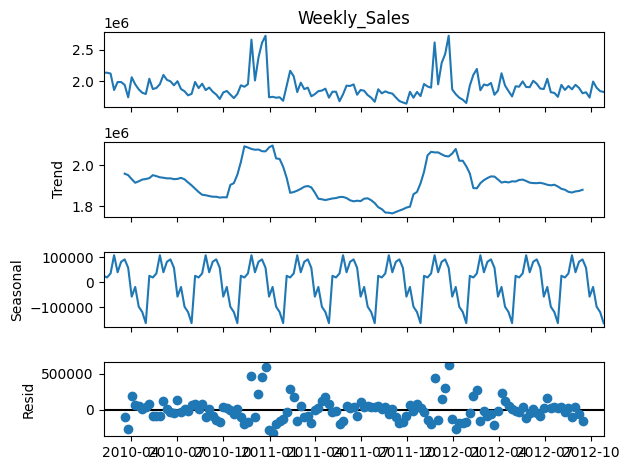

In [99]:
# Importing the seasonal decompose for break down the components of the time series data
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition=seasonal_decompose(store2_sales['Weekly_Sales'],period=13)
print(decomposition.plot())

In [100]:
mean1=store2_sales.rolling(window=10).mean() # Creating the Rolling mean
std1=store2_sales.rolling(window=10).std() # Creating the Rolling standard deviation

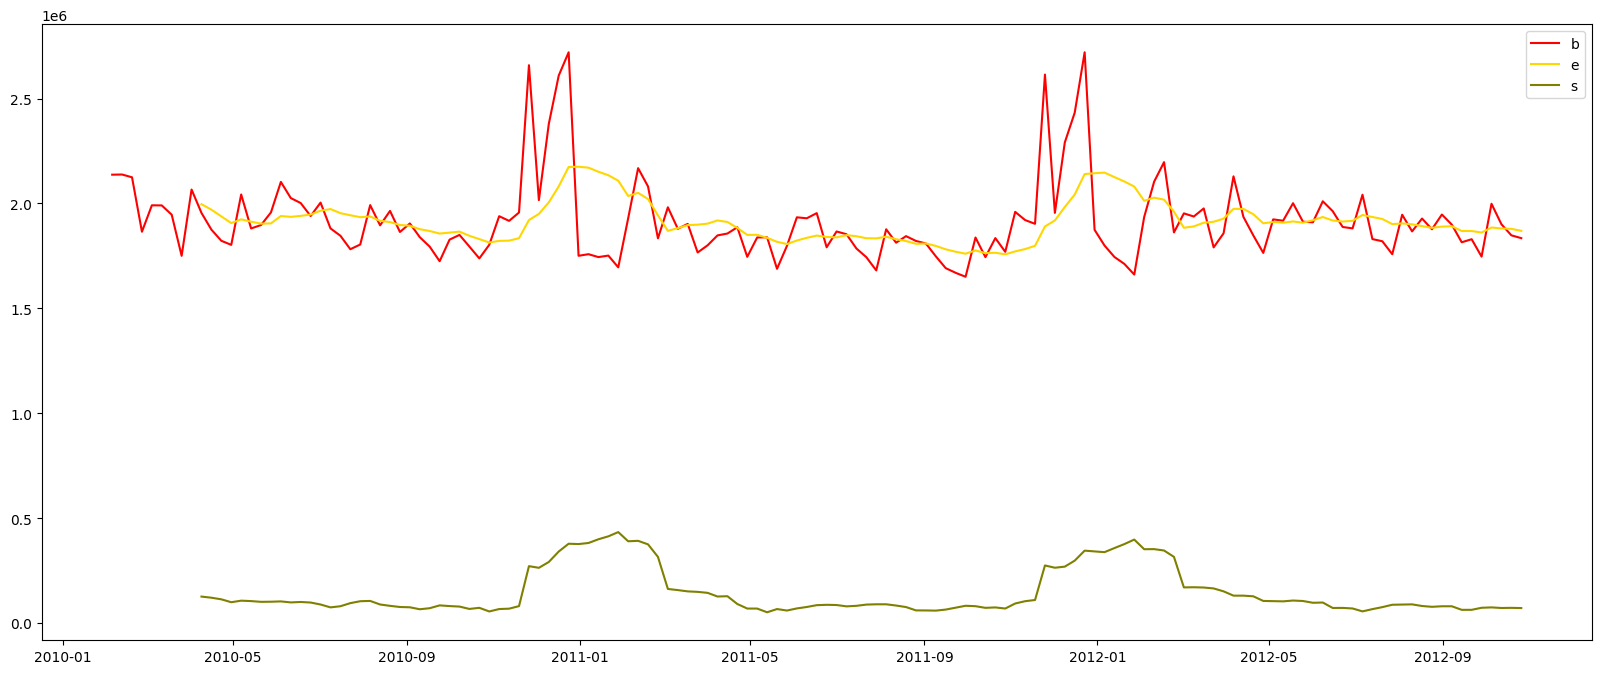

In [101]:
# plotting the rolling mean
plt.figure(figsize=(20,8))
orig=plt.plot(store2_sales['Weekly_Sales'],color='red',label='Original')
mean=plt.plot(mean1,color='gold',label='Rolling Mean')
std=plt.plot(std1,color='olive',label='Rolling Std')
plt.legend('best')
plt.show(block=False)

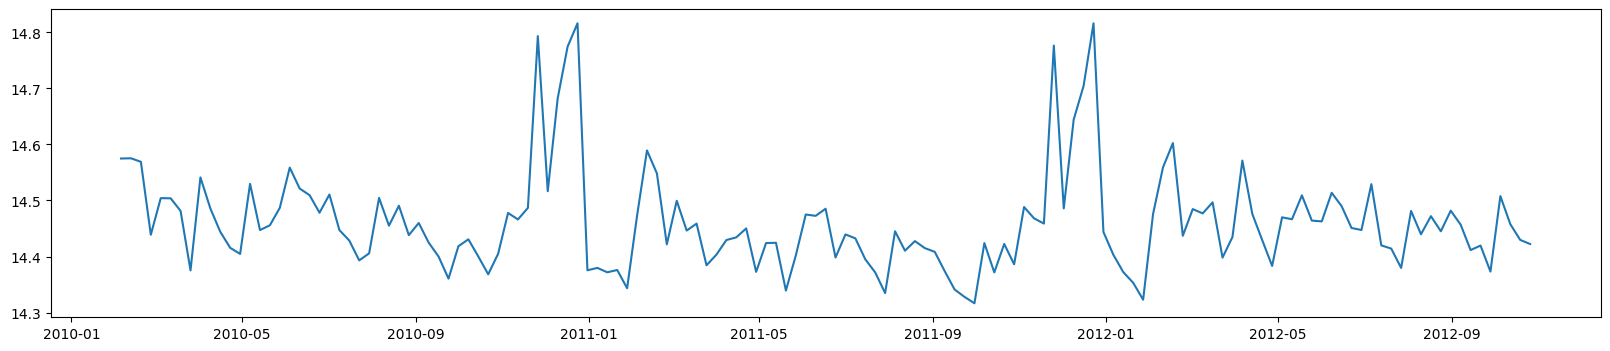

In [102]:
df_log = np.log(store2_sales)# applying log transformation to the data
plt.figure(figsize=(20,4))
plt.plot(df_log)

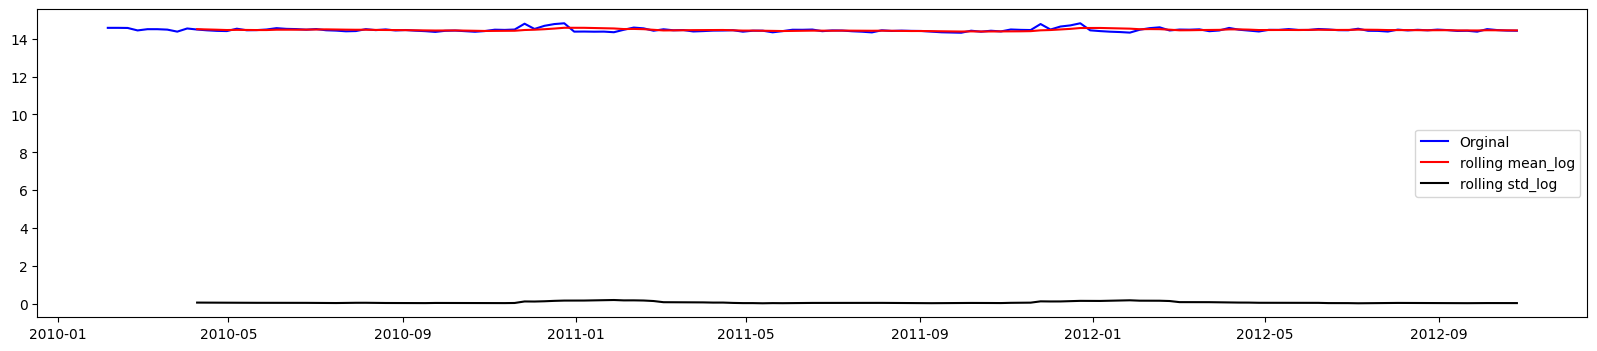

In [103]:
# After the log transformation to the data we are comparing the actual data with rolling mean and standard deviation
mean_log = df_log.rolling(window = 10).mean()
std_log = df_log.rolling(window = 10).std()
plt.figure(figsize=(20,4))
plt.plot(df_log,color= 'blue',label = 'Orginal')
plt.plot(mean_log, color = 'red', label = 'rolling mean_log')
plt.plot(std_log, color = 'black', label = 'rolling std_log')
plt.legend(loc = 'best')
plt.show()


In [104]:
df_new = df_log - mean_log #subtracting the log data and mean log data
df_new.head(20)

,Weekly_Sales
Date,
2010-02-05,NaN
2010-02-12,NaN
2010-02-19,NaN
2010-02-26,NaN
2010-03-05,NaN
2010-03-12,NaN
2010-03-19,NaN
2010-03-26,NaN
2010-04-02,NaN


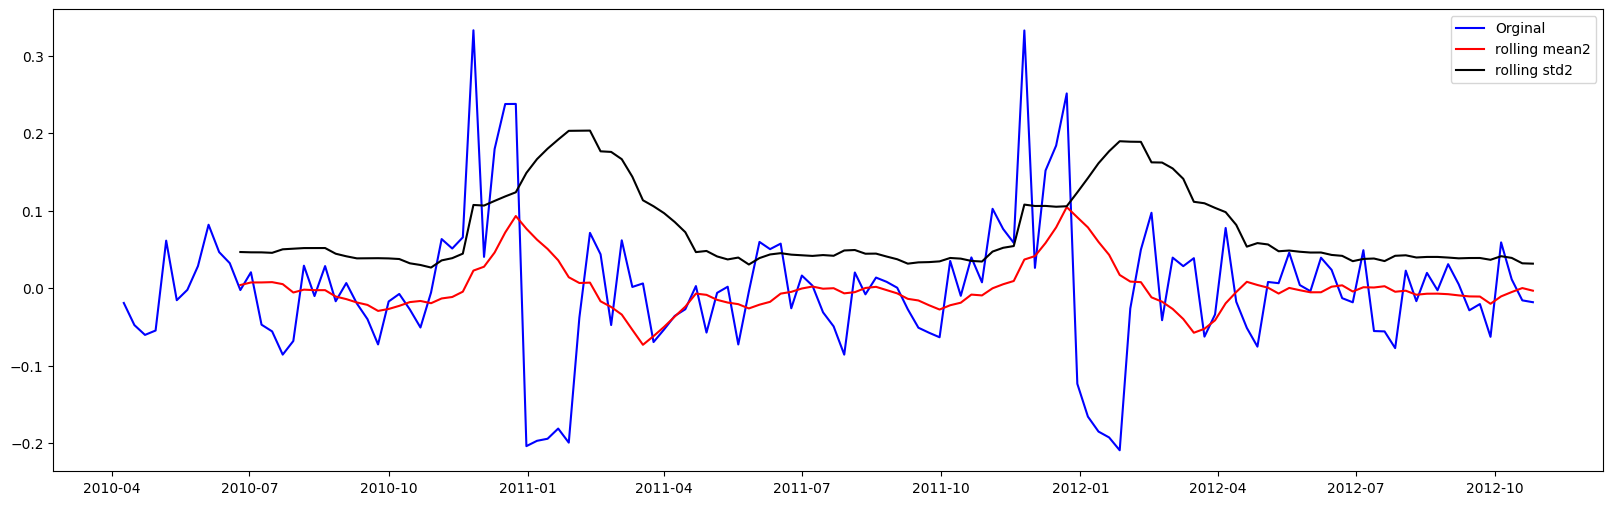

In [105]:
df_new.dropna(inplace = True) # dropping the nan values
# after the log transformation checking rolling stastics such as mean and standard deviation
mean2 = df_new.rolling(window = 12).mean()
std2 = df_new.rolling(window = 12).std()

plt.figure(figsize=(20,6))
plt.plot(df_new,color= 'blue',label = 'Orginal')
plt.plot(mean2, color = 'red', label = 'rolling mean2')
plt.plot(std2, color = 'black', label = 'rolling std2')
plt.legend(loc = 'best')
plt.show()

In [106]:
adf_test(df_new['Weekly_Sales'],title='ADF TEST') # Checking the Data stationarity again after the log transformation

Augmented Dickey-Fuller Test: ADF TEST
ADF test statistic     -6.950758e+00
p-value                 9.706666e-10
# lags used             4.000000e+00
# observations          1.290000e+02
critical value (1%)    -3.482088e+00
critical value (5%)    -2.884219e+00
critical value (10%)   -2.578864e+00
Rejects the null hypothesis
Data has no unit root and is stationary


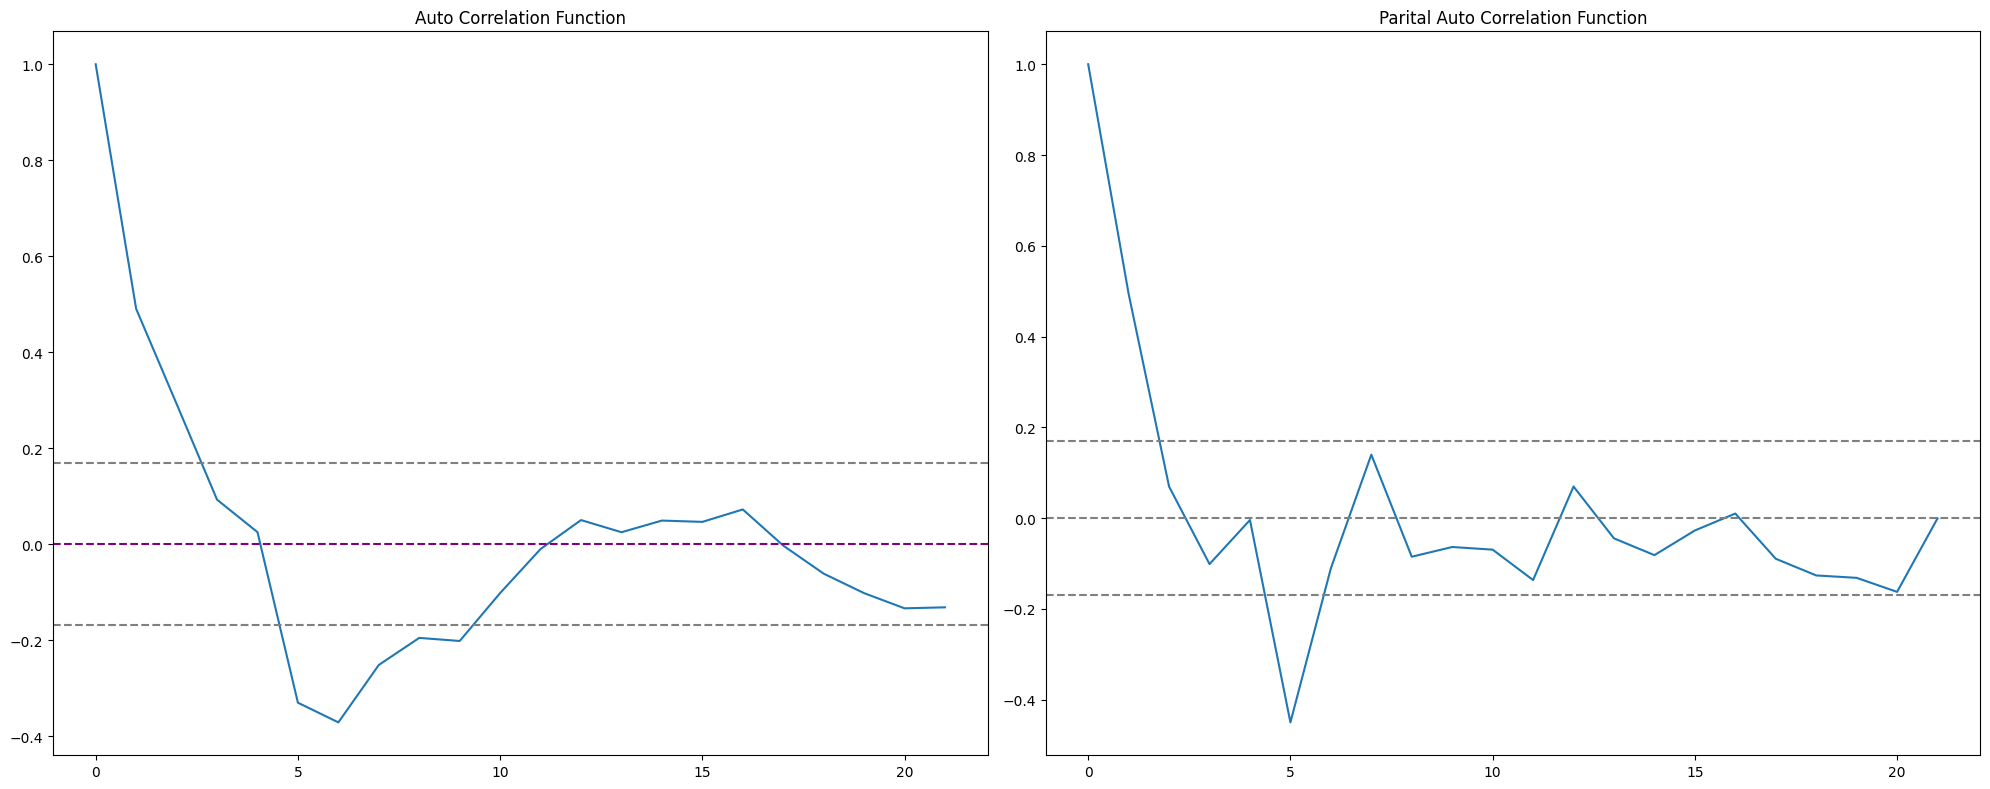

In [107]:
# plotting the acf and pacf plot to identify the values of P AND Q
from statsmodels.tsa.stattools import acf,pacf
lag_acf=acf(df_new)
lag_pacf=pacf(df_new)


# Plot ACf
plt.figure(figsize=(20,8))
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y=0,linestyle='--',color='purple')
plt.axhline(y=-1.96/np.sqrt(len(df_new)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(df_new)),linestyle='--',color='gray')
plt.title('Auto Correlation Function')
plt.tight_layout()

plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(df_new)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(df_new)),linestyle='--',color='gray')
plt.title('Parital Auto Correlation Function')
plt.tight_layout()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


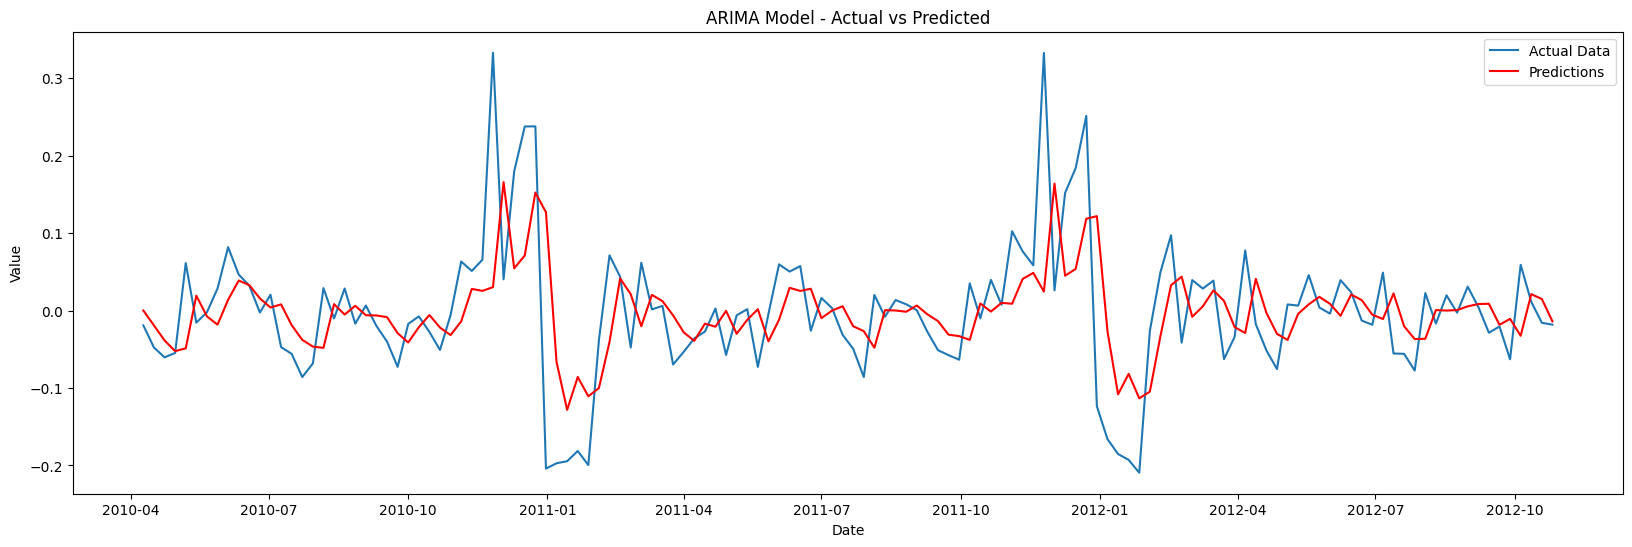

In [108]:
p, d, q = 2, 1, 2  # I have got pdq values as 2,2,2
model = ARIMA(df_new, order=(p, d, q))# fitting the model
arima_result = model.fit()

# Get predictions on historical data
predictions = arima_result.predict()
plt.figure(figsize=(20,6))
plt.plot(df_new, label='Actual Data')
plt.plot(predictions, color='red', label='Predictions')
plt.title('ARIMA Model - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [109]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(df_new,predictions)
print(f'Mean Squared_Error  {mse}')

Mean Squared_Error  0.005975748106430301


In [110]:
rmse=np.sqrt(mse)
print(f'Root Mean Squared_Error  {rmse}')

Root Mean Squared_Error  0.07730296311546085


In [111]:
forecast_steps = 12
forecast = arima_result.forecast(steps=forecast_steps)


In [112]:
end_date_actual_data = '2012-12-10' # here i need to find my dataset end date. so that i can continue from there to next 12 weeks

# Generate dates for the forecasted period
# with the help of datetime function iam creating a time span of 12 weeks
forecast_start_date = pd.to_datetime(end_date_actual_data) + pd.DateOffset(weeks=0)
forecast_end_date = forecast_start_date + pd.DateOffset(weeks=len(forecast))
forecast_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='W')

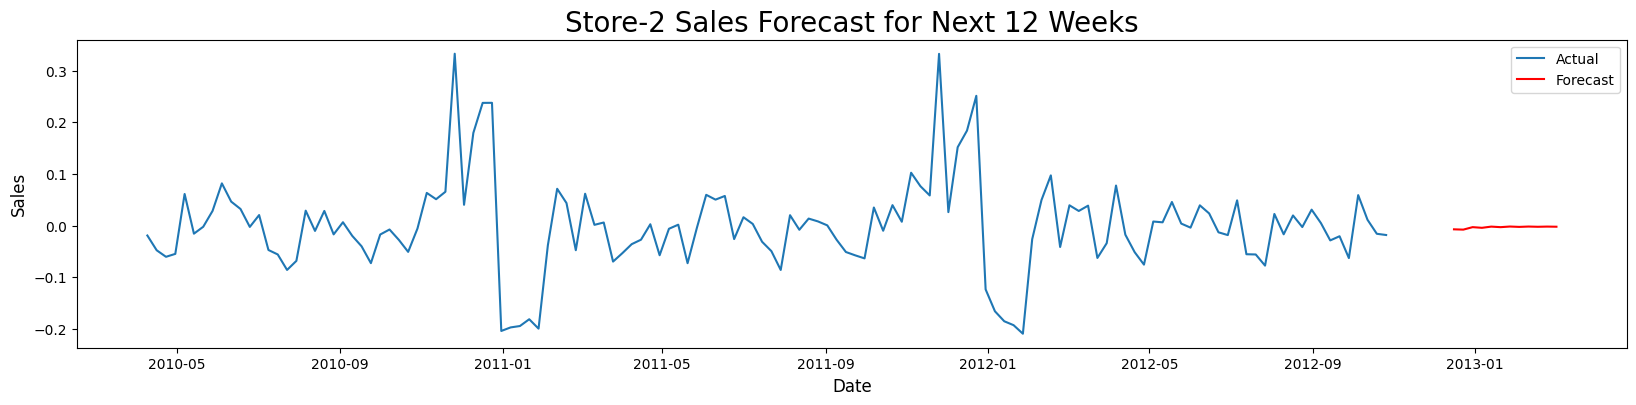

In [113]:
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted_Sales': forecast})
forecast_df.set_index('Date',inplace=True)
plt.figure(figsize=(20, 4))
plt.plot(df_new, label='Actual')
plt.plot(forecast_df, label='Forecast', color='red')
plt.title('Store-2 Sales Forecast for Next 12 Weeks',fontsize=20)
plt.xlabel('Date',fontsize=12)
plt.ylabel('Sales',fontsize=12)
plt.legend()
plt.show()

In [114]:
forecast_dates

DatetimeIndex(['2012-12-16', '2012-12-23', '2012-12-30', '2013-01-06',
               '2013-01-13', '2013-01-20', '2013-01-27', '2013-02-03',
               '2013-02-10', '2013-02-17', '2013-02-24', '2013-03-03'],
              dtype='datetime64[ns]', freq='W-SUN')

In [115]:
# Checking the Model Accuracy once again
rmse=np.sqrt(mse)
print(f'Root Mean Squared_Error {rmse}')

Root Mean Squared_Error 0.07730296311546085


**Store 5 Sales Forecast**

In [116]:
# Creating a new data frame for store 6 sales forecast
store5_sales=df[df['Store']==5].groupby('Date')['Weekly_Sales'].sum().reset_index()
store5_sales.set_index('Date',inplace=True) # Setting the date as index
adf_test(store5_sales['Weekly_Sales'],title='ADF TEST')

Augmented Dickey-Fuller Test: ADF TEST
ADF test statistic       -4.310974
p-value                   0.000425
# lags used               4.000000
# observations          138.000000
critical value (1%)      -3.478648
critical value (5%)      -2.882722
critical value (10%)     -2.578065
Rejects the null hypothesis
Data has no unit root and is stationary


Figure(640x480)


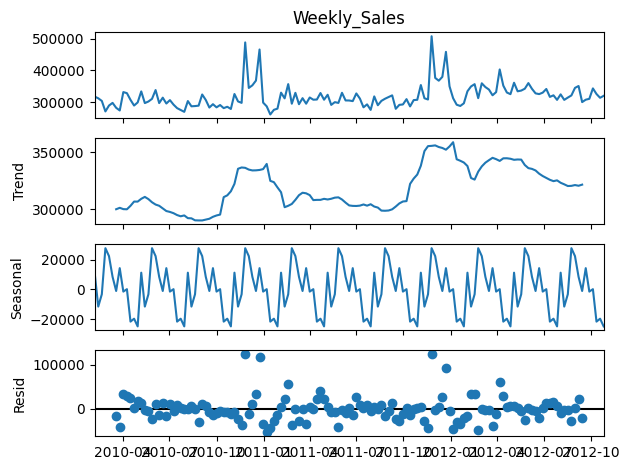

In [117]:
decomposition=seasonal_decompose(store5_sales['Weekly_Sales'],period=13)# plotting the components of time series data
print(decomposition.plot())

In [118]:
mean1=store5_sales.rolling(window=10).mean() # Creating the Rolling mean
std1=store5_sales.rolling(window=10).std() # Creating the Rolling standard deviation

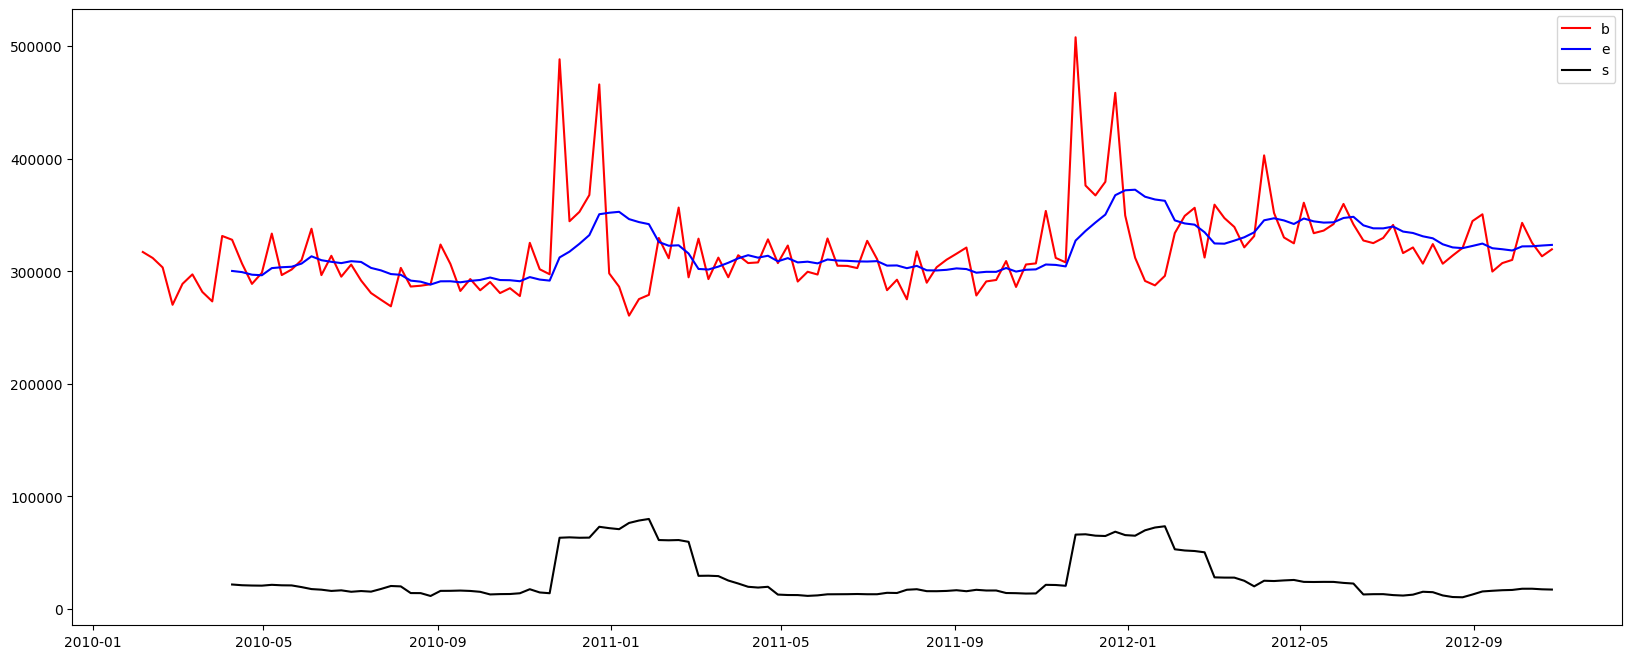

In [119]:
# plotting the rolling mean
plt.figure(figsize=(20,8))
orig=plt.plot(store5_sales['Weekly_Sales'],color='red',label='Original')
mean=plt.plot(mean1,color='blue',label='Rolling Mean')
std=plt.plot(std1,color='black',label='Rolling Std')
plt.legend('best')
plt.show(block=False)

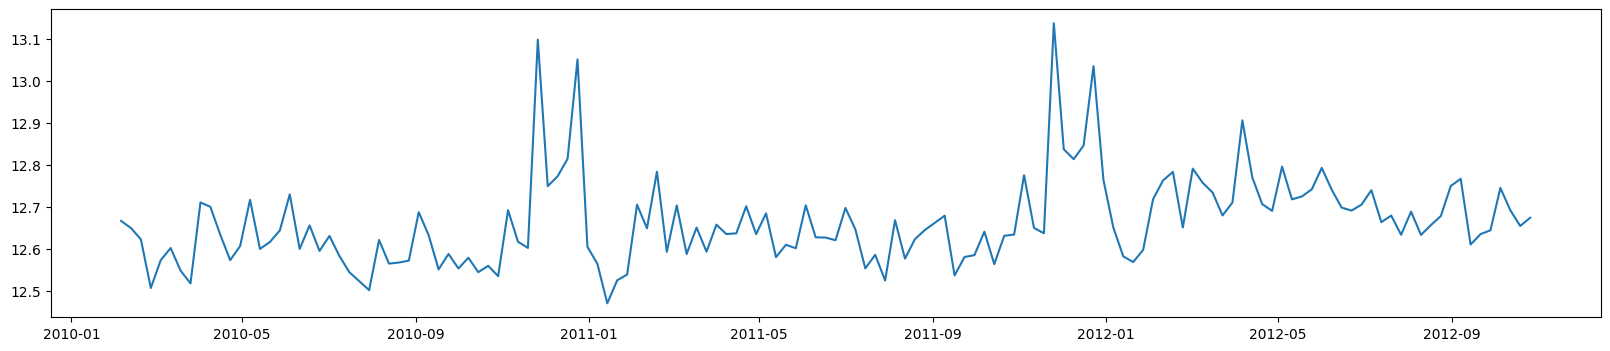

In [120]:
df_log = np.log(store5_sales)
plt.figure(figsize=(20,4))
plt.plot(df_log)

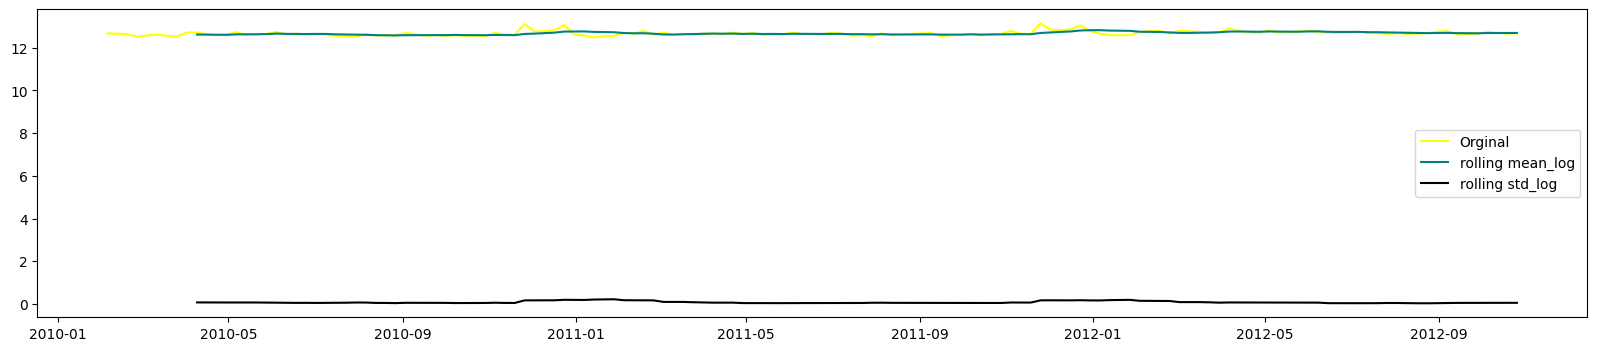

In [121]:
# After the log transformation to the data we are comparing the actual data with rolling mean and standard deviation
mean_log = df_log.rolling(window = 10).mean()
std_log = df_log.rolling(window = 10).std()
plt.figure(figsize=(20,4))
plt.plot(df_log,color= 'yellow',label = 'Orginal')
plt.plot(mean_log, color = 'teal', label = 'rolling mean_log')
plt.plot(std_log, color = 'black', label = 'rolling std_log')
plt.legend(loc = 'best')
plt.show()

In [122]:
df_new = df_log - mean_log
df_new.head(10)

,Weekly_Sales
Date,
2010-02-05,NaN
2010-02-12,NaN
2010-02-19,NaN
2010-02-26,NaN
2010-03-05,NaN
2010-03-12,NaN
2010-03-19,NaN
2010-03-26,NaN
2010-04-02,NaN


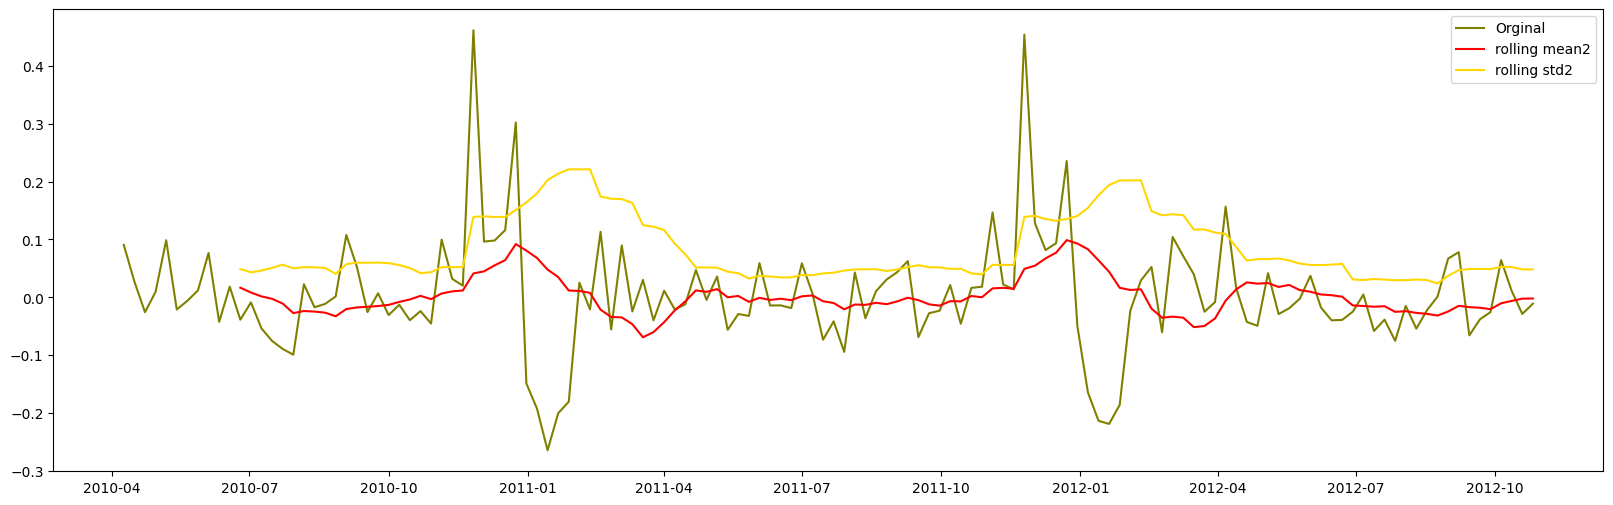

In [123]:
df_new.dropna(inplace = True) # dropping the nan values
# after the log transformation checking rolling stastics such as mean and standard deviation
mean2 = df_new.rolling(window = 12).mean()
std2 = df_new.rolling(window = 12).std()

plt.figure(figsize=(20,6))
plt.plot(df_new,color= 'olive',label = 'Orginal')
plt.plot(mean2, color = 'red', label = 'rolling mean2')
plt.plot(std2, color = 'gold', label = 'rolling std2')
plt.legend(loc = 'best')
plt.show()

In [124]:
adf_test(df_new['Weekly_Sales'],title='ADF TEST')

Augmented Dickey-Fuller Test: ADF TEST
ADF test statistic     -6.463484e+00
p-value                 1.424074e-08
# lags used             5.000000e+00
# observations          1.280000e+02
critical value (1%)    -3.482501e+00
critical value (5%)    -2.884398e+00
critical value (10%)   -2.578960e+00
Rejects the null hypothesis
Data has no unit root and is stationary


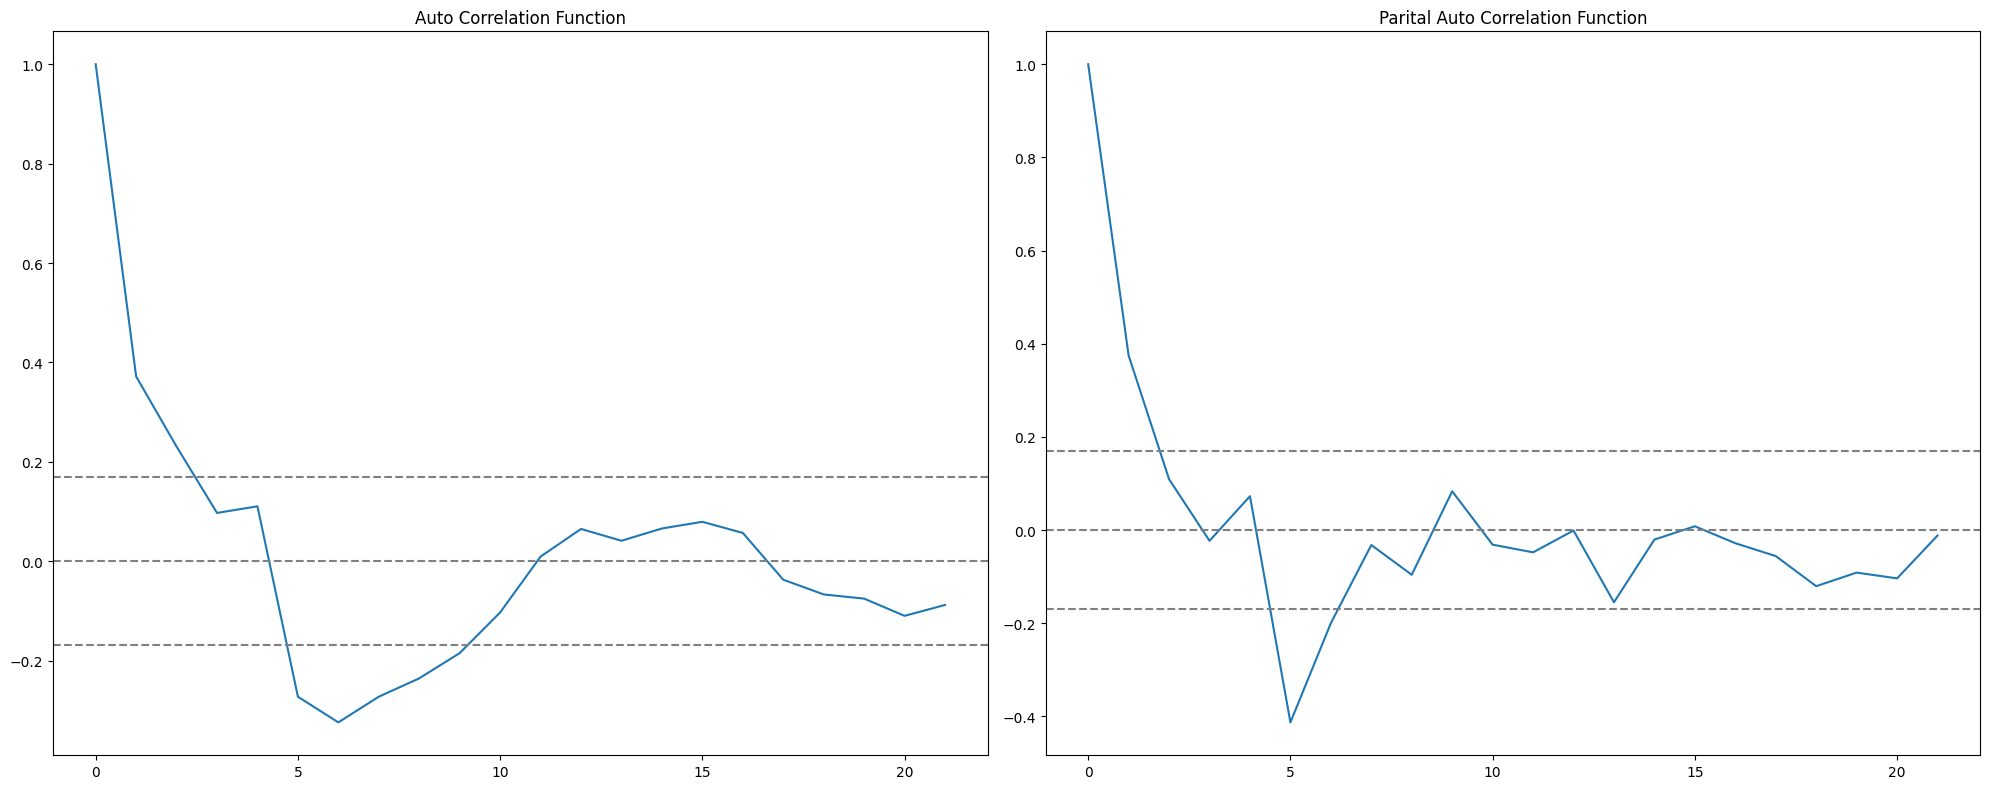

In [125]:
# plotting the acf and pacf plot to identify the values of P AND Q
from statsmodels.tsa.stattools import acf,pacf
lag_acf=acf(df_new)
lag_pacf=pacf(df_new)


# Plot ACf
plt.figure(figsize=(20,8))
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(df_new)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(df_new)),linestyle='--',color='gray')
plt.title('Auto Correlation Function')
plt.tight_layout()

plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(df_new)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(df_new)),linestyle='--',color='gray')
plt.title('Parital Auto Correlation Function')
plt.tight_layout()

In [126]:
#pdq values are 4,1,3
p, d, q = 4, 1, 3  # I have got pdq values as 2,2,2
model = ARIMA(df_new, order=(p, d, q))# fitting the model
arima_result = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


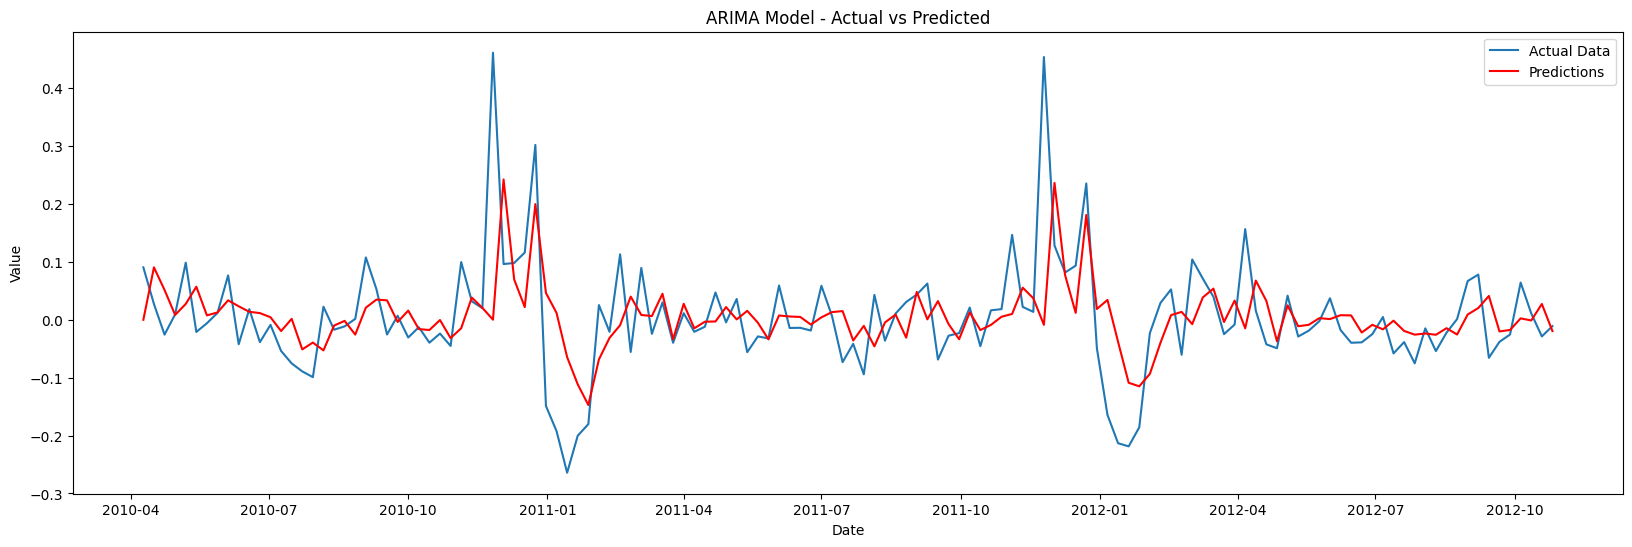

In [127]:
# Get predictions on historical data
predictions = arima_result.predict()
# Plotting the actual and predictions
plt.figure(figsize=(20,6))
plt.plot(df_new, label='Actual Data')
plt.plot(predictions, color='red', label='Predictions')
plt.title('ARIMA Model - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [128]:

# Combine actual and predicted into one DataFrame and drop NaNs
eval_df = pd.concat([df_new, predictions], axis=1)
eval_df.columns = ['actual', 'predicted']
eval_df = eval_df.dropna()

# Now calculate MSE safely
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(eval_df['actual'], eval_df['predicted'])

print(f"Mean Squared Error (MSE): {mse:.4f}")

Mean Squared Error (MSE): 0.0077


In [129]:
rmse=np.sqrt(mse) # Checking the accuracy of the model with rmse
print(f'Root Mean Squared_Error  {rmse}')

Root Mean Squared_Error  0.08756193840142307


In [130]:
forecast_steps = 12 # Forcasting the for the next 12 weeks
forecast = arima_result.forecast(steps=forecast_steps)

In [131]:
end_date_actual_data = '2012-12-10' # here i need to find my dataset end date. so that i can continue from there to next 12 weeks


In [132]:
# Generate dates for the forecasted period
# with the help of datetime function iam creating a time span of 12 weeks
forecast_start_date = pd.to_datetime(end_date_actual_data) + pd.DateOffset(weeks=0)
forecast_end_date = forecast_start_date + pd.DateOffset(weeks=len(forecast))
forecast_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='W')


In [133]:
# creating a dataframe with forecasted sales and next 12 weeks dates
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted_Sales': forecast})
forecast_df.set_index('Date',inplace=True) # setting the date as an index

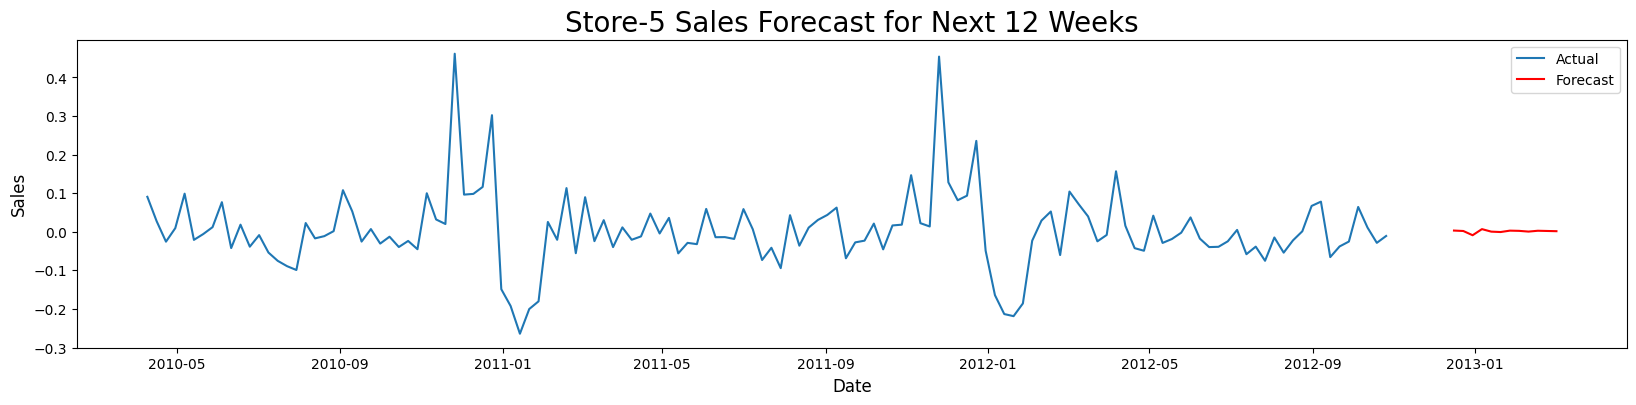

In [134]:
plt.figure(figsize=(20, 4))# plotting the actual and forcaste sales for next 12 weeks
plt.plot(df_new, label='Actual')
plt.plot(forecast_df, label='Forecast', color='red')
plt.title('Store-5 Sales Forecast for Next 12 Weeks',fontsize=20)
plt.xlabel('Date',fontsize=12)
plt.ylabel('Sales',fontsize=12)
plt.legend()
plt.show()

In [135]:
# Checking the Model Accuracy once again
rmse=np.sqrt(mse)
print(f'Root Mean Squared_Error {rmse}')

Root Mean Squared_Error 0.08756193840142307


**Store 11th Sales Prediction**

In [136]:
# Creating a new data frame for store 11 sales forecast
store11_sales=df[df['Store']==11].groupby('Date')['Weekly_Sales'].sum().reset_index()

In [137]:
store11_sales.set_index('Date',inplace=True) # Setting the date as index

In [138]:
adf_test(store11_sales['Weekly_Sales'],title='ADF TEST') # Checking the pvalue and data stationarity

Augmented Dickey-Fuller Test: ADF TEST
ADF test statistic       -3.762354
p-value                   0.003317
# lags used               6.000000
# observations          136.000000
critical value (1%)      -3.479372
critical value (5%)      -2.883037
critical value (10%)     -2.578234
Rejects the null hypothesis
Data has no unit root and is stationary


Figure(640x480)


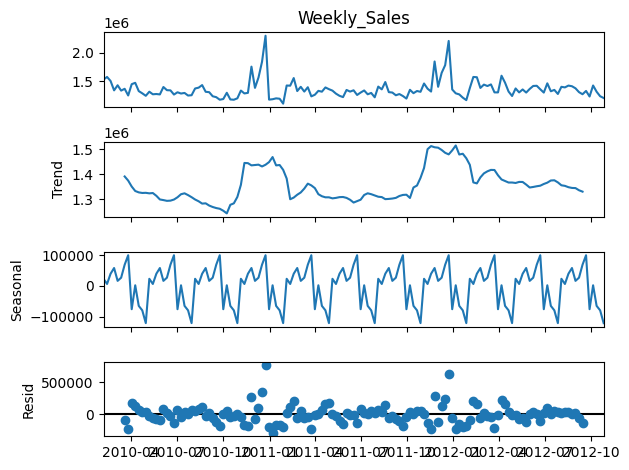

In [139]:
decomposition=seasonal_decompose(store11_sales['Weekly_Sales'],period=13)
print(decomposition.plot())

In [140]:
mean1=store11_sales.rolling(window=10).mean() # Creating the Rolling mean
std1=store11_sales.rolling(window=10).std() # Creating the Rolling standard deviation


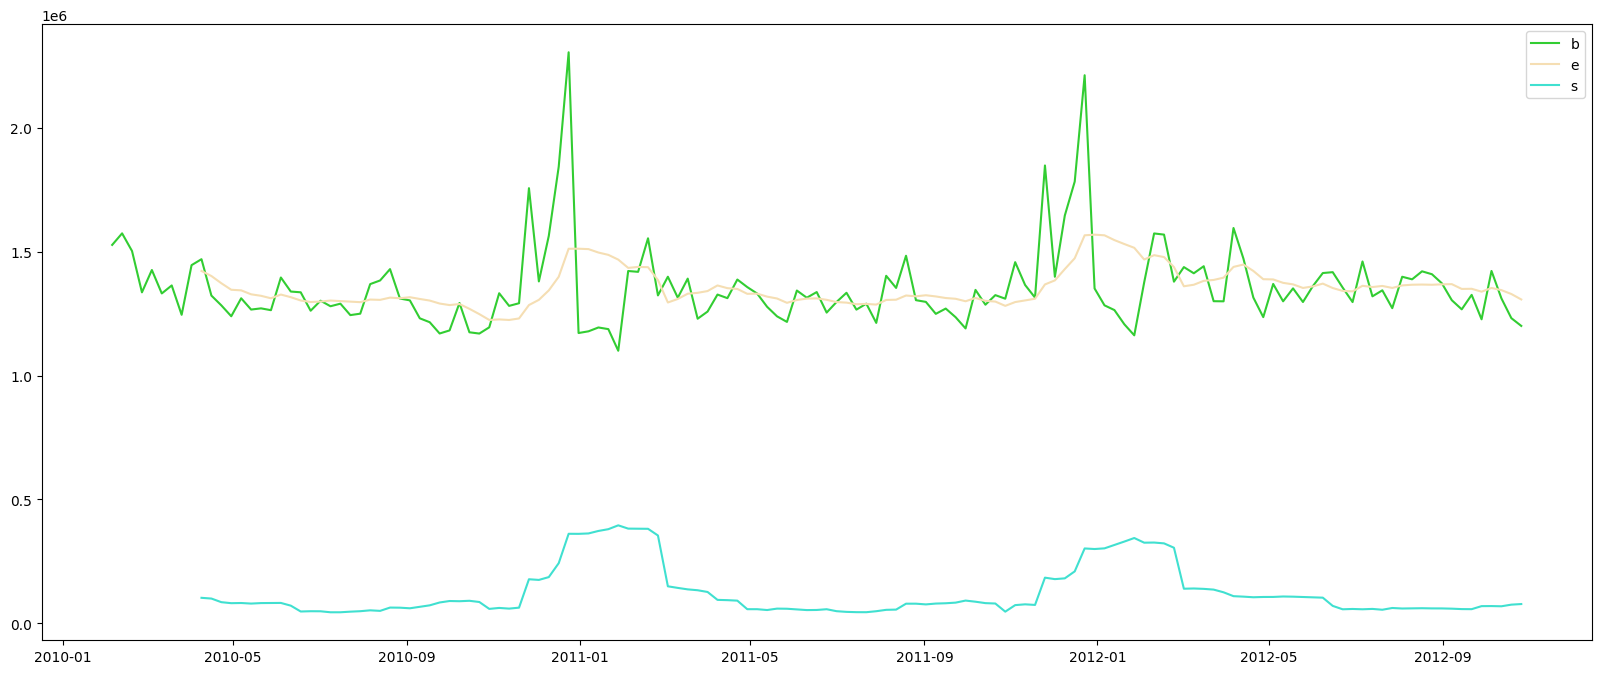

In [141]:
# plotting the rolling mean
plt.figure(figsize=(20,8))
orig=plt.plot(store11_sales['Weekly_Sales'],color='limegreen',label='Original')
mean=plt.plot(mean1,color='wheat',label='Rolling Mean')
std=plt.plot(std1,color='turquoise',label='Rolling Std')
plt.legend('best')
plt.show(block=False)

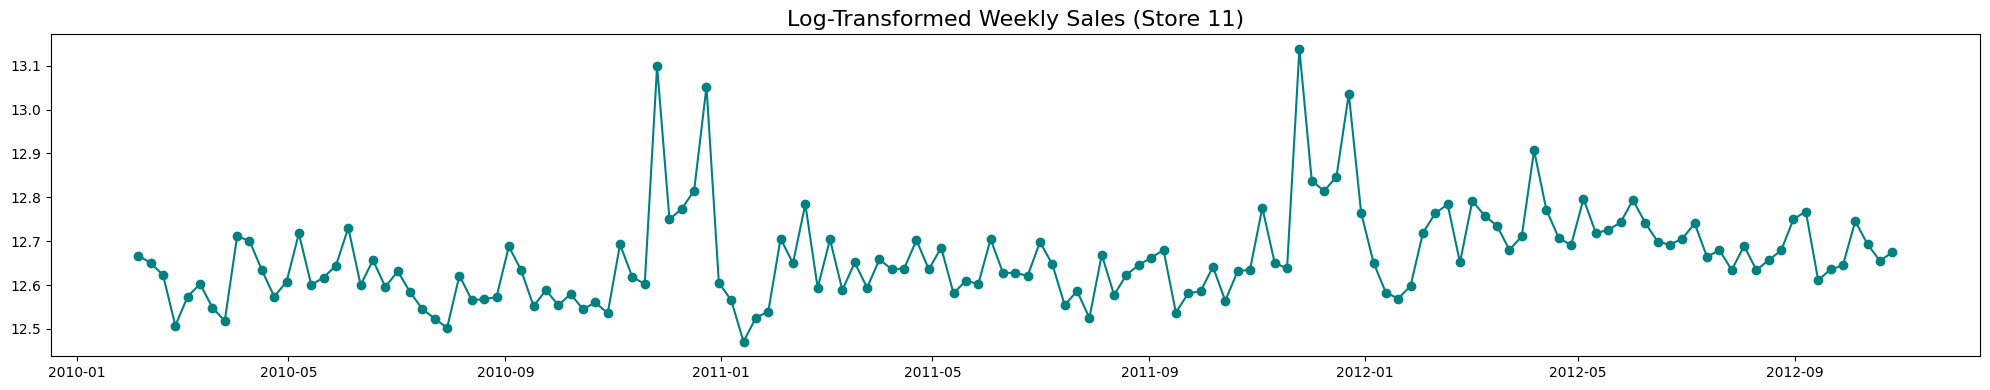

In [142]:
plt.figure(figsize=(20, 4))
plt.plot(df_log, marker='o',color='teal')
plt.title('Log-Transformed Weekly Sales (Store 11)', fontsize=16)
plt.tight_layout()
plt.show()

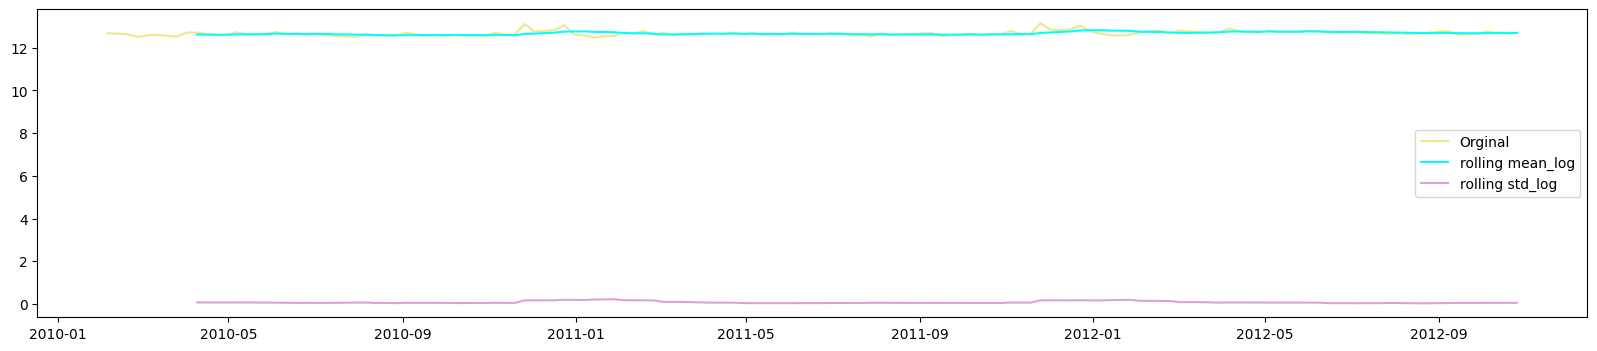

In [143]:
mean_log = df_log.rolling(window = 10).mean()
std_log = df_log.rolling(window = 10).std()
plt.figure(figsize=(20,4))
plt.plot(df_log,color= 'khaki',label = 'Orginal')
plt.plot(mean_log, color = 'aqua', label = 'rolling mean_log')
plt.plot(std_log, color = 'plum', label = 'rolling std_log')
plt.legend(loc = 'best')
plt.show()

In [144]:
df_new = df_log - mean_log
df_new.head(20)

,Weekly_Sales
Date,
2010-02-05,NaN
2010-02-12,NaN
2010-02-19,NaN
2010-02-26,NaN
2010-03-05,NaN
2010-03-12,NaN
2010-03-19,NaN
2010-03-26,NaN
2010-04-02,NaN


In [145]:
df_new.dropna(inplace = True) # dropping the nan values
# after the log transformation checking rolling stastics such as mean and standard deviation
mean2 = df_new.rolling(window = 12).mean()
std2 = df_new.rolling(window = 12).std()

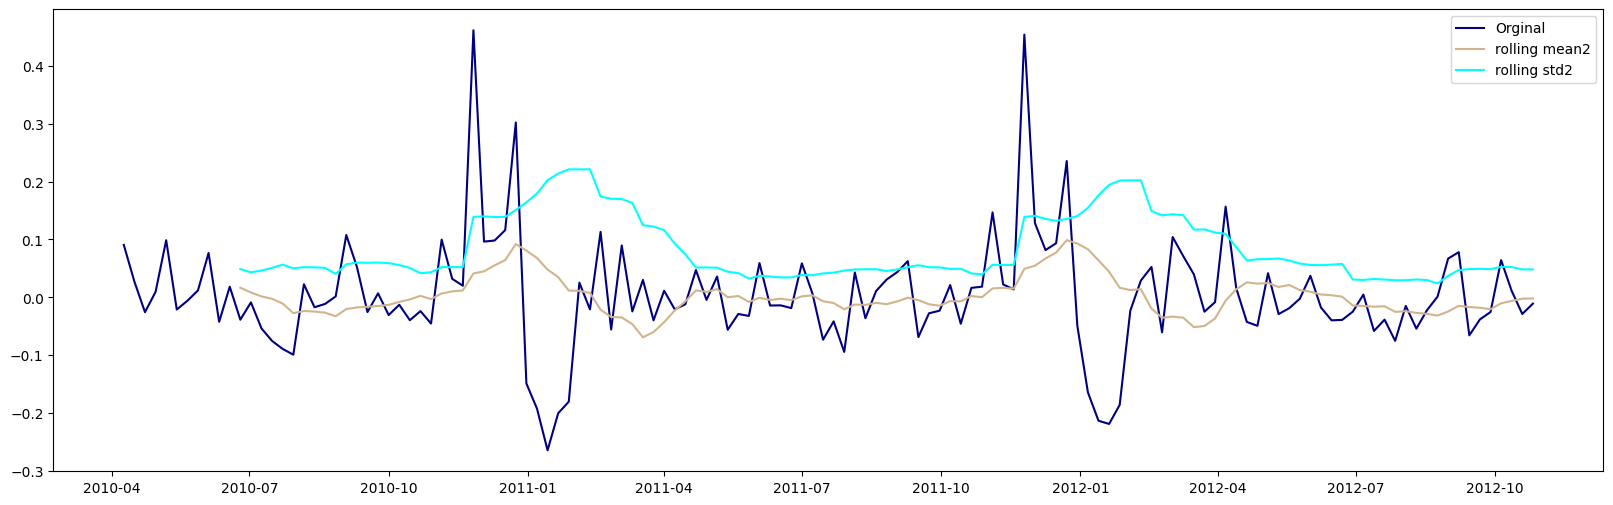

In [146]:
plt.figure(figsize=(20,6))
plt.plot(df_new,color= 'navy',label = 'Orginal')
plt.plot(mean2, color = 'tan', label = 'rolling mean2')
plt.plot(std2, color = 'cyan', label = 'rolling std2')
plt.legend(loc = 'best')
plt.show()

In [147]:
adf_test(df_new['Weekly_Sales'],title='ADF TEST')

Augmented Dickey-Fuller Test: ADF TEST
ADF test statistic     -6.463484e+00
p-value                 1.424074e-08
# lags used             5.000000e+00
# observations          1.280000e+02
critical value (1%)    -3.482501e+00
critical value (5%)    -2.884398e+00
critical value (10%)   -2.578960e+00
Rejects the null hypothesis
Data has no unit root and is stationary


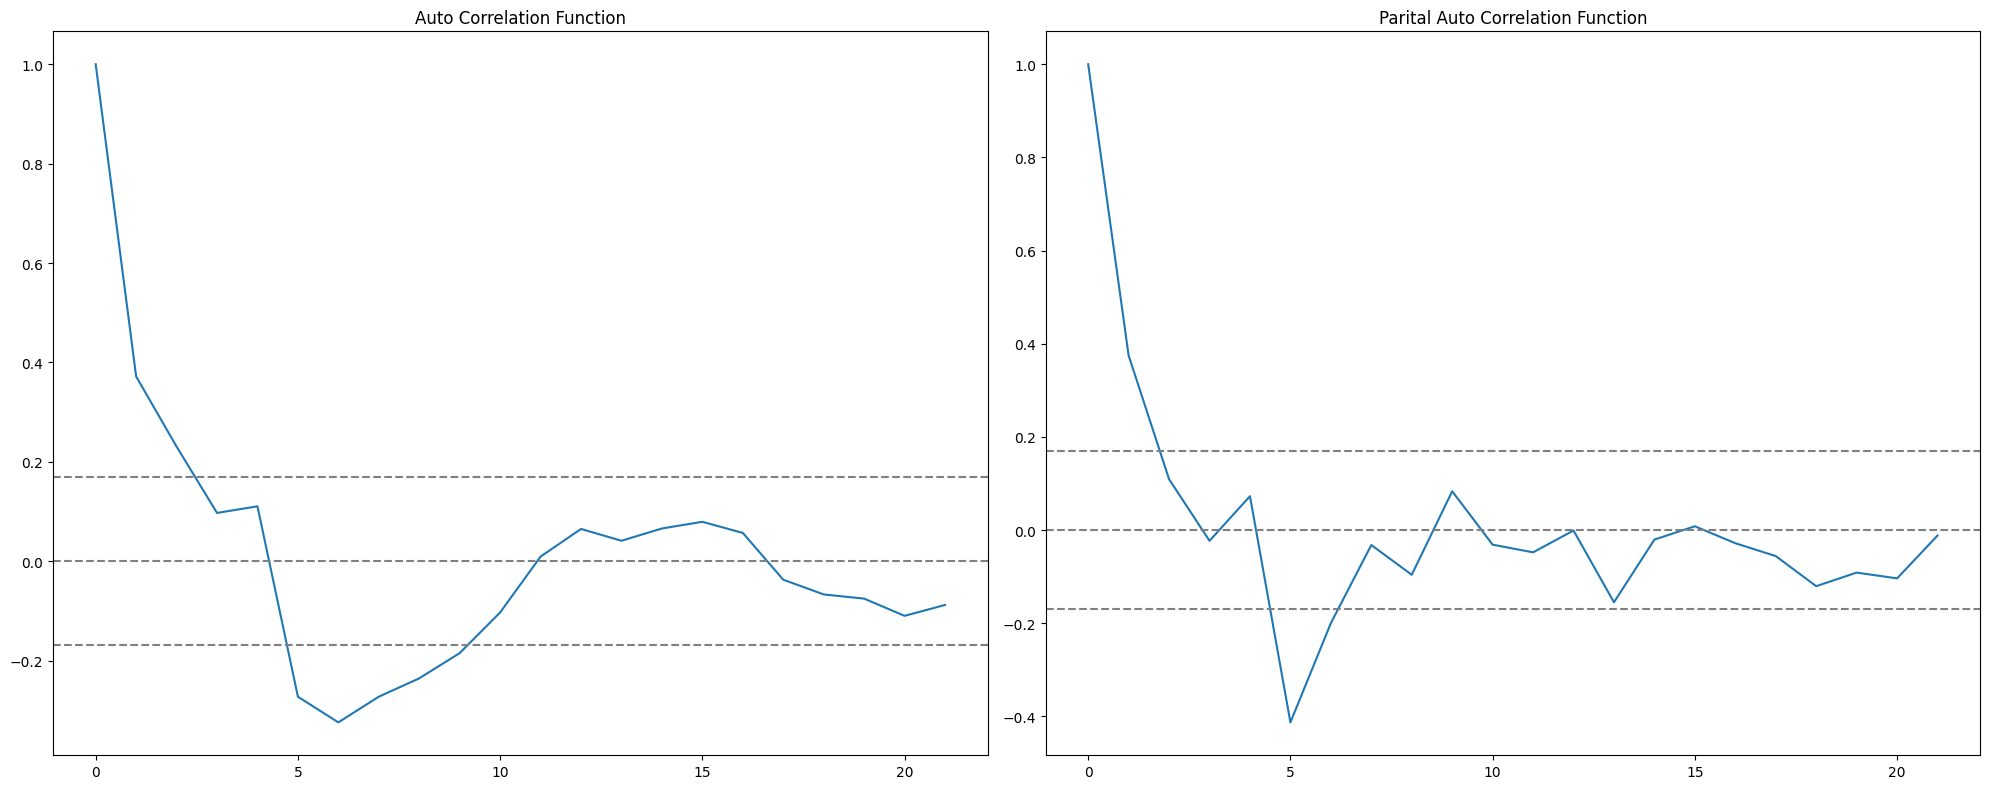

In [148]:
# plotting the acf and pacf plot to identify the values of P AND Q
from statsmodels.tsa.stattools import acf,pacf
lag_acf=acf(df_new)
lag_pacf=pacf(df_new)

# Plot ACf
plt.figure(figsize=(20,8))
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(df_new)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(df_new)),linestyle='--',color='gray')
plt.title('Auto Correlation Function')
plt.tight_layout()

plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(df_new)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(df_new)),linestyle='--',color='gray')
plt.title('Parital Auto Correlation Function')
plt.tight_layout()

In [149]:
p, d, q = 3, 1, 2  # I have got pdq values as 2,2,2
model = ARIMA(df_new, order=(p, d, q))# fitting the model
arima_result = model.fit()

# Get predictions on historical data
predictions = arima_result.predict()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


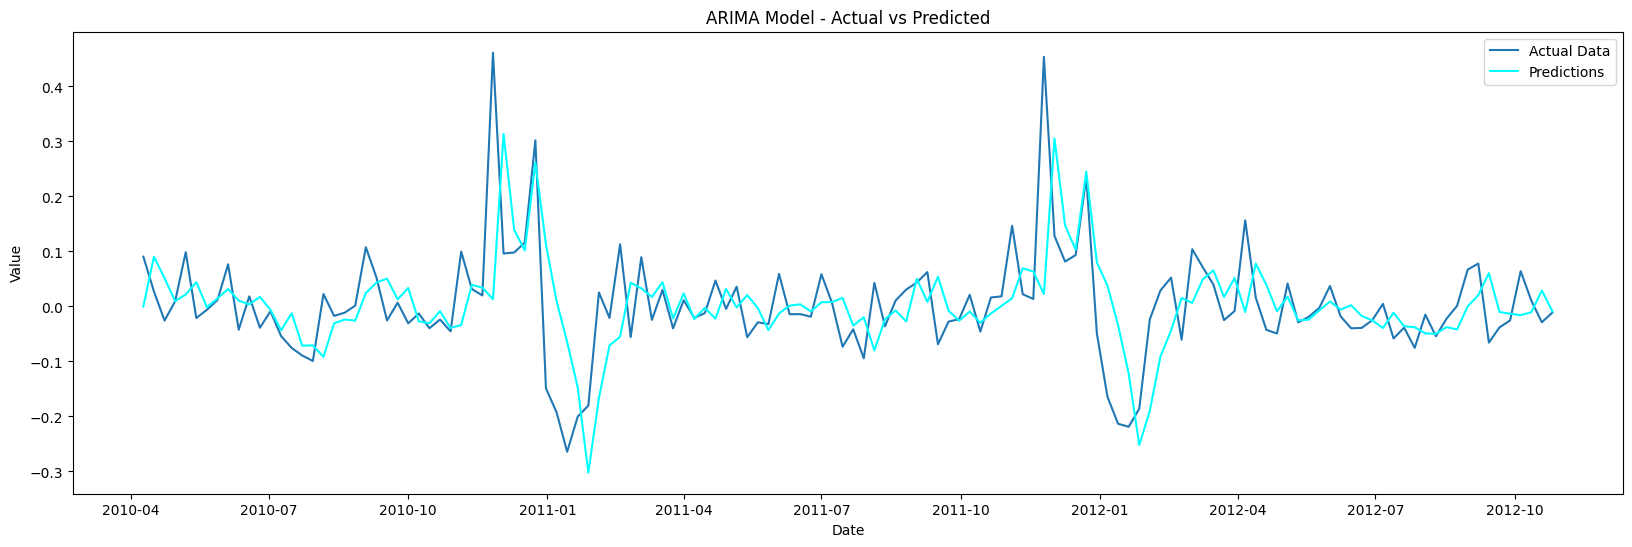

In [150]:
# Plotting the actual and predictions
plt.figure(figsize=(20,6))
plt.plot(df_new, label='Actual Data')
plt.plot(predictions, color='cyan', label='Predictions')
plt.title('ARIMA Model - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [151]:
mse=mean_squared_error(df_new,predictions) # Checking the accuracy of the model with mse
print(f'Mean Squared_Error  {mse}')

Mean Squared_Error  0.008783775807295939


In [152]:
rmse=np.sqrt(mse) # Checking the accuracy of the model with rmse
print(f'Root Mean Squared_Error  {rmse}')

Root Mean Squared_Error  0.09372180006431768


In [153]:
forecast_steps = 12 # Forcasting the for the next 12 weeks
forecast = arima_result.forecast(steps=forecast_steps)

In [154]:
end_date_actual_data = '2012-12-10' # here i need to find my dataset end date. so that i can continue from there to next 12 weeks
#Generate dates for the forecasted period
# with the help of datetime function iam creating a time span of 12 weeks
forecast_start_date = pd.to_datetime(end_date_actual_data) + pd.DateOffset(weeks=0)
forecast_end_date = forecast_start_date + pd.DateOffset(weeks=len(forecast))
forecast_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='W')

In [155]:
# creating a dataframe with forecasted sales and next 12 weeks dates
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted_Sales': forecast})

In [156]:
forecast_df.set_index('Date',inplace=True)

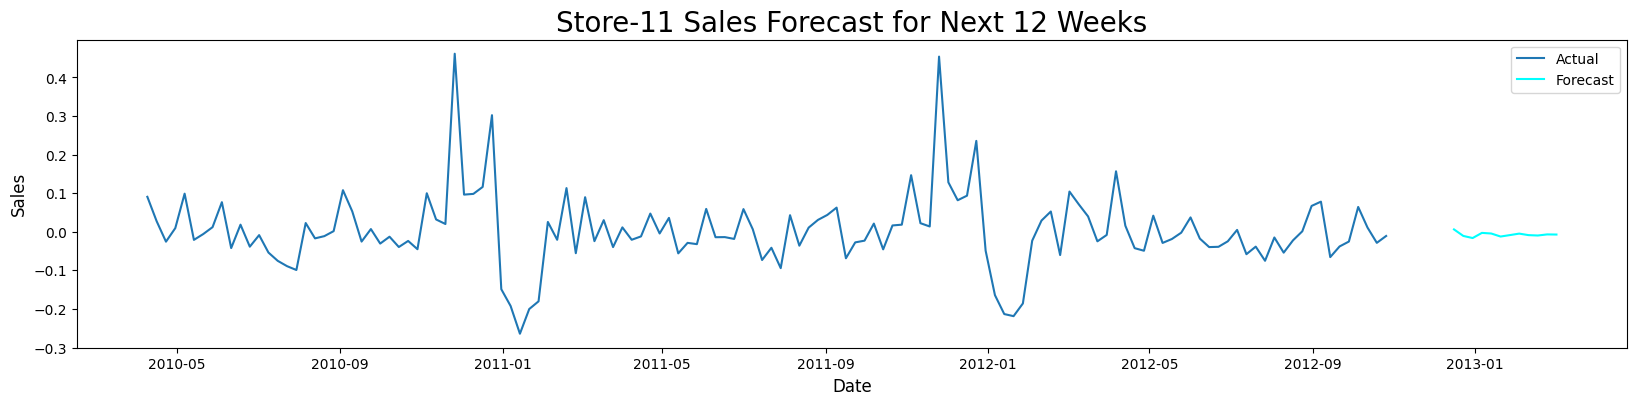

In [157]:
plt.figure(figsize=(20, 4))# plotting the actual and forcaste sales for next 12 weeks
plt.plot(df_new, label='Actual')
plt.plot(forecast_df, label='Forecast', color='aqua')
plt.title('Store-11 Sales Forecast for Next 12 Weeks',fontsize=20)
plt.xlabel('Date',fontsize=12)
plt.ylabel('Sales',fontsize=12)
plt.legend()
plt.show()

In [158]:
# Checking the Model Accuracy once again
rmse=np.sqrt(mse)
print(f'Root Mean Squared_Error {rmse}')

Root Mean Squared_Error 0.09372180006431768


**Store 16th Sales Prediction**

In [159]:
# Creating a new data frame for store 11 sales forecast
store16_sales=df[df['Store']==16].groupby('Date')['Weekly_Sales'].sum().reset_index()

In [160]:
store16_sales.set_index('Date',inplace=True) # Setting the date as index

In [161]:
adf_test(store16_sales['Weekly_Sales'],title='ADF TEST')

Augmented Dickey-Fuller Test: ADF TEST
ADF test statistic       -4.525758
p-value                   0.000177
# lags used               4.000000
# observations          138.000000
critical value (1%)      -3.478648
critical value (5%)      -2.882722
critical value (10%)     -2.578065
Rejects the null hypothesis
Data has no unit root and is stationary


Figure(640x480)


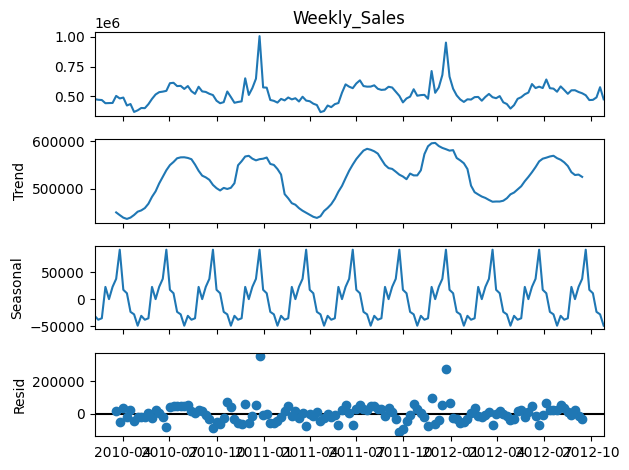

In [162]:
# plotting the components of time series data
decomposition=seasonal_decompose(store16_sales['Weekly_Sales'],period=13)
print(decomposition.plot())

In [163]:
mean1=store16_sales.rolling(window=10).mean() # Creating the Rolling mean
std1=store16_sales.rolling(window=10).std() # Creating the Rolling standard deviation

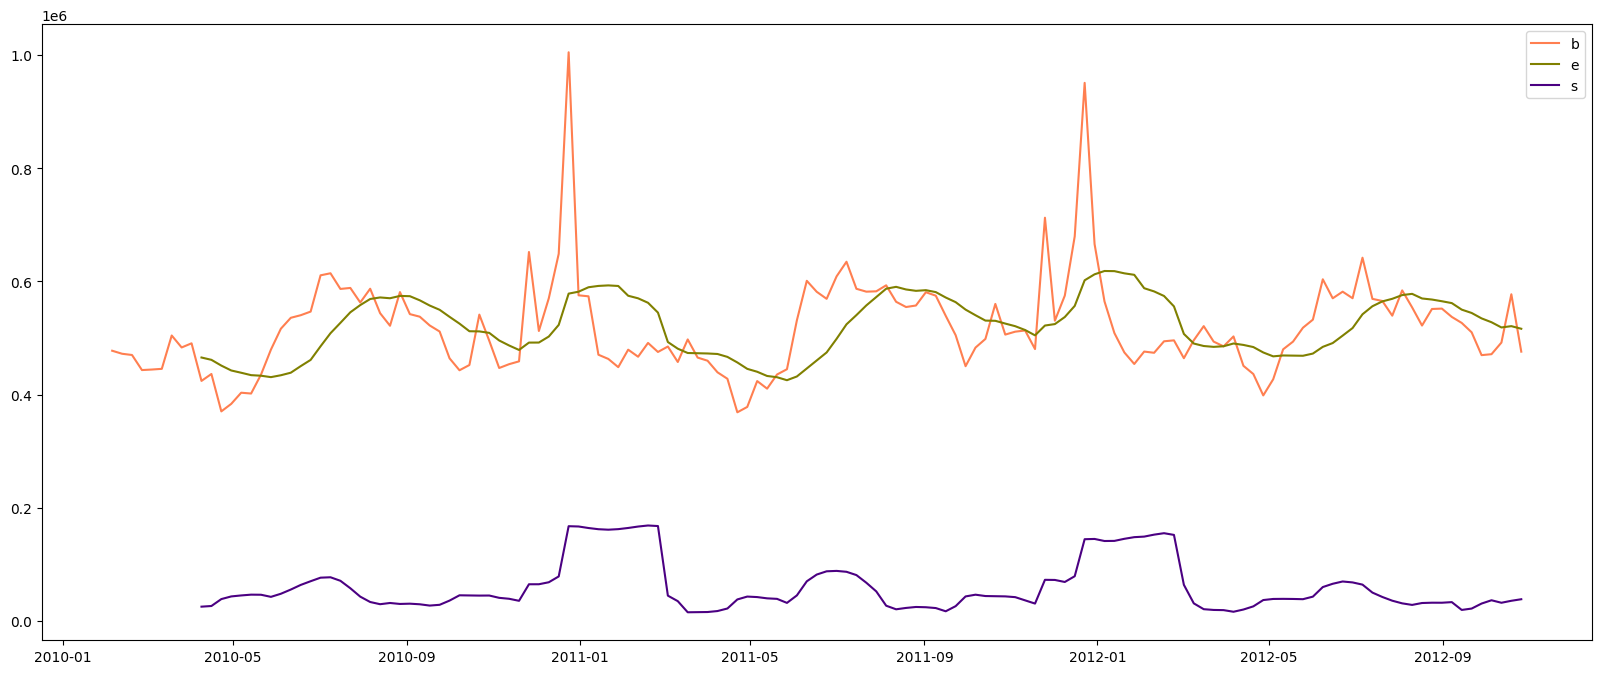

In [164]:
# plotting the rolling mean
plt.figure(figsize=(20,8))
orig=plt.plot(store16_sales['Weekly_Sales'],color='coral',label='Original')
mean=plt.plot(mean1,color='olive',label='Rolling Mean')
std=plt.plot(std1,color='indigo',label='Rolling Std')
plt.legend('best')
plt.show(block=False)

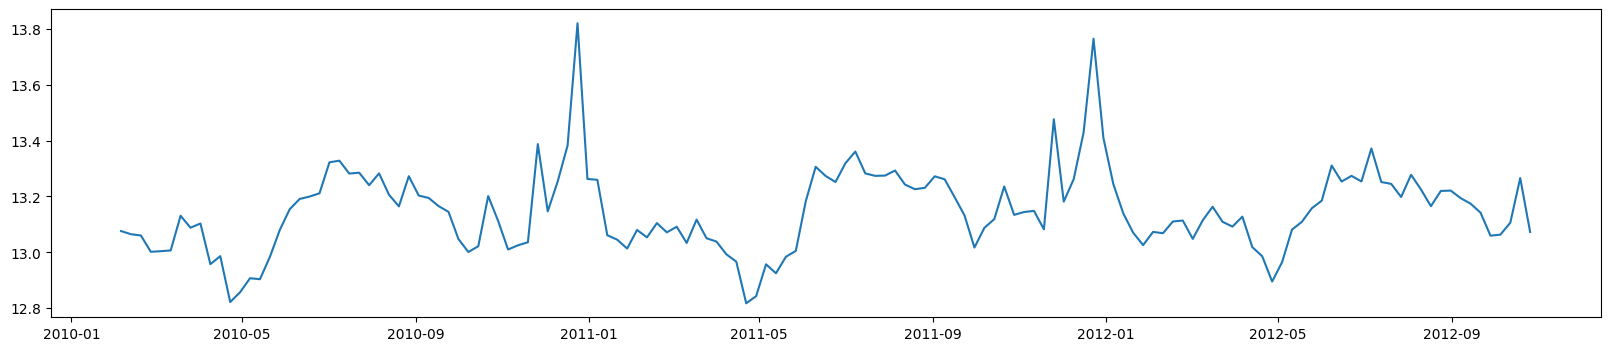

In [165]:
df_log = np.log(store16_sales)# applaying log transformation to the data
plt.figure(figsize=(20,4))
plt.plot(df_log)

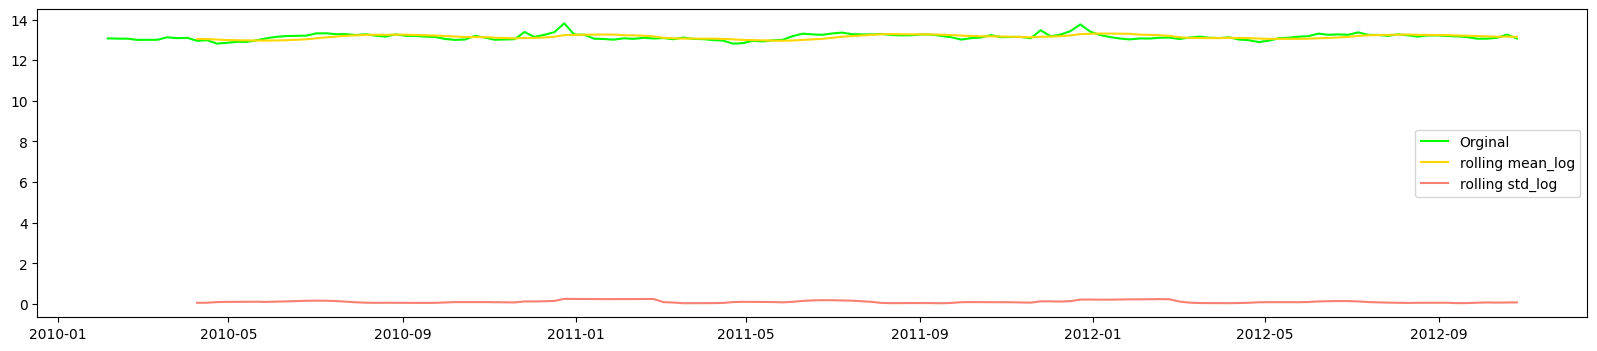

In [166]:
mean_log = df_log.rolling(window = 10).mean()
std_log = df_log.rolling(window = 10).std()
plt.figure(figsize=(20,4))
plt.plot(df_log,color= 'lime',label = 'Orginal')
plt.plot(mean_log, color = 'gold', label = 'rolling mean_log')
plt.plot(std_log, color = 'salmon', label = 'rolling std_log')
plt.legend(loc = 'best')
plt.show()

In [167]:
df_new = df_log - mean_log
df_new.head(20)

,Weekly_Sales
Date,
2010-02-05,NaN
2010-02-12,NaN
2010-02-19,NaN
2010-02-26,NaN
2010-03-05,NaN
2010-03-12,NaN
2010-03-19,NaN
2010-03-26,NaN
2010-04-02,NaN


In [168]:
df_new.dropna(inplace = True) # dropping the nan values

In [169]:
# after the log transformation checking rolling stastics such as mean and standard deviation
mean2 = df_new.rolling(window = 12).mean()
std2 = df_new.rolling(window = 12).std()

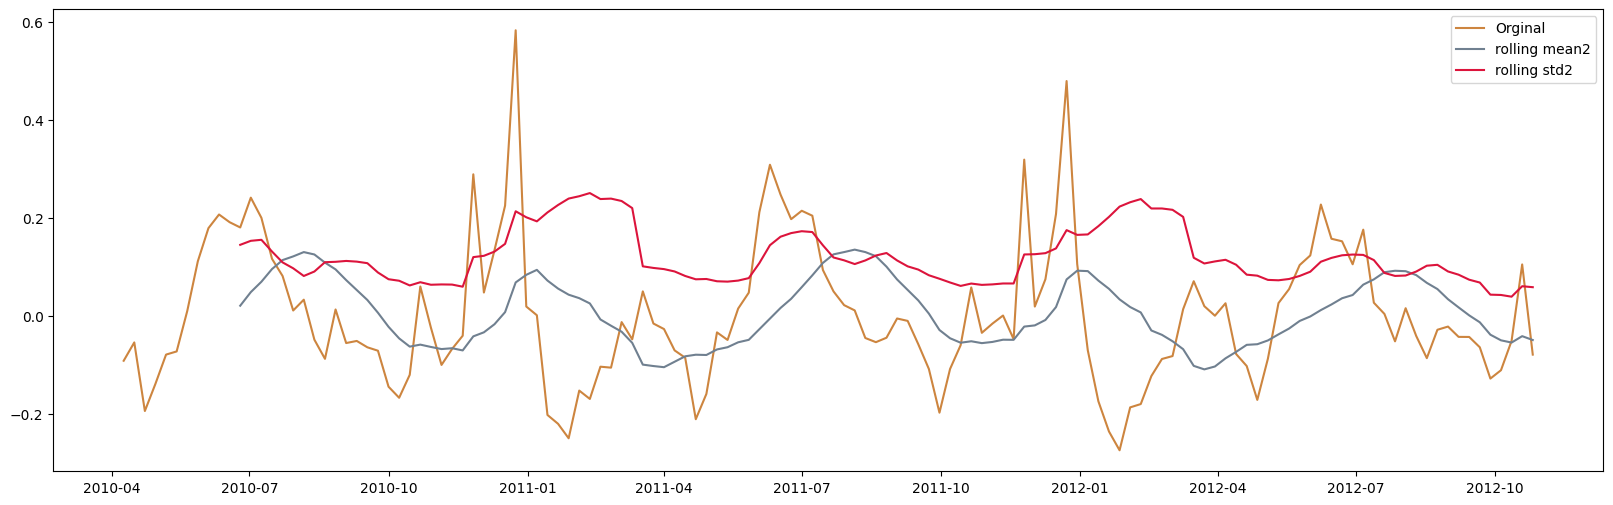

In [170]:
plt.figure(figsize=(20,6))
plt.plot(df_new,color= 'peru',label = 'Orginal')
plt.plot(mean2, color = 'slategray', label = 'rolling mean2')
plt.plot(std2, color = 'crimson', label = 'rolling std2')
plt.legend(loc = 'best')
plt.show()

In [171]:
# Clean the series: replace inf with NaN, then drop NaNs
series_clean = df_new['Weekly_Sales'].replace([np.inf, -np.inf], np.nan).dropna()

# Run ADF test on cleaned data
adf_test(series_clean, title='ADF Test on Weekly Sales (Cleaned)')


Augmented Dickey-Fuller Test: ADF Test on Weekly Sales (Cleaned)
ADF test statistic       -5.511747
p-value                   0.000002
# lags used               4.000000
# observations          129.000000
critical value (1%)      -3.482088
critical value (5%)      -2.884219
critical value (10%)     -2.578864
Rejects the null hypothesis
Data has no unit root and is stationary


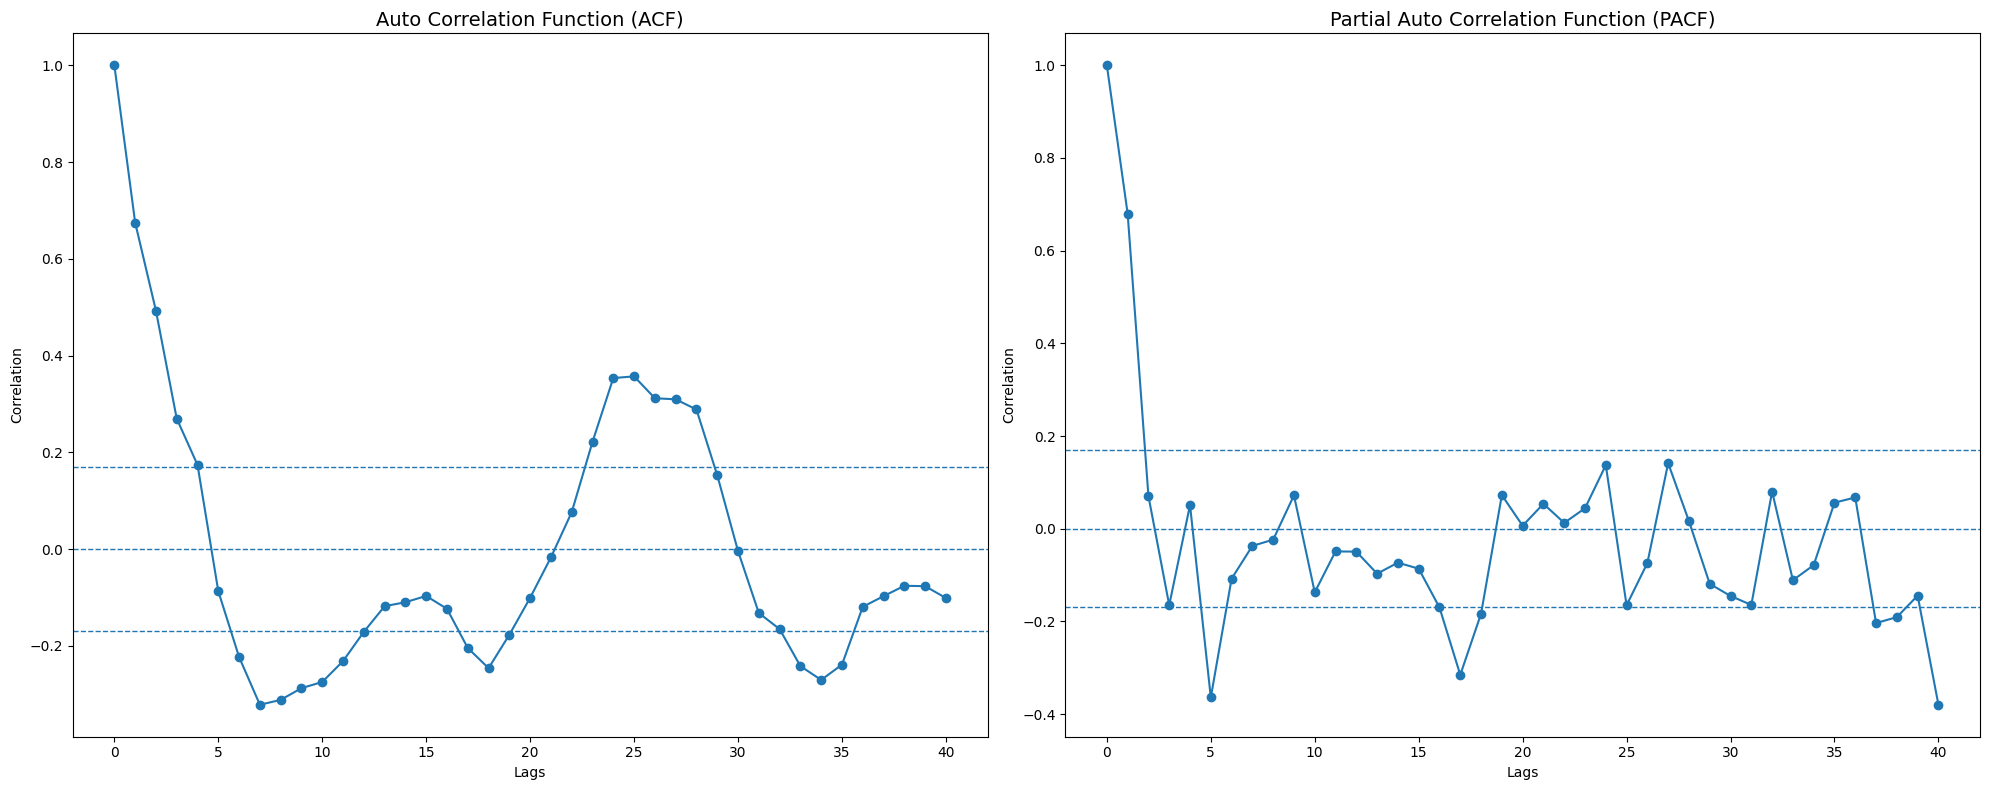

In [172]:
from statsmodels.tsa.stattools import acf, pacf
import numpy as np
import matplotlib.pyplot as plt

# Make sure you're passing the series (not the full DataFrame)
series = df_new['Weekly_Sales'].dropna()

lag_acf = acf(series, nlags=40)
lag_pacf = pacf(series, nlags=40)

# Plot ACF and PACF
plt.figure(figsize=(20, 8))

# ACF Plot
plt.subplot(121)
plt.plot(lag_acf, marker='o')
plt.axhline(y=0, linestyle='--', linewidth=1)
plt.axhline(y=-1.96/np.sqrt(len(series)), linestyle='--', linewidth=1)
plt.axhline(y=1.96/np.sqrt(len(series)), linestyle='--', linewidth=1)
plt.title('Auto Correlation Function (ACF)', fontsize=14)
plt.xlabel('Lags')
plt.ylabel('Correlation')

# PACF Plot
plt.subplot(122)
plt.plot(lag_pacf, marker='o')
plt.axhline(y=0, linestyle='--', linewidth=1)
plt.axhline(y=-1.96/np.sqrt(len(series)), linestyle='--', linewidth=1)
plt.axhline(y=1.96/np.sqrt(len(series)), linestyle='--', linewidth=1)
plt.title('Partial Auto Correlation Function (PACF)', fontsize=14)
plt.xlabel('Lags')
plt.ylabel('Correlation')

plt.tight_layout()
plt.show()


In [173]:
#pdq values are 3,1,3
p, d, q = 3, 1, 3  # I have got pdq values as 2,2,2
model = ARIMA(df_new, order=(p, d, q))# fitting the model
arima_result = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


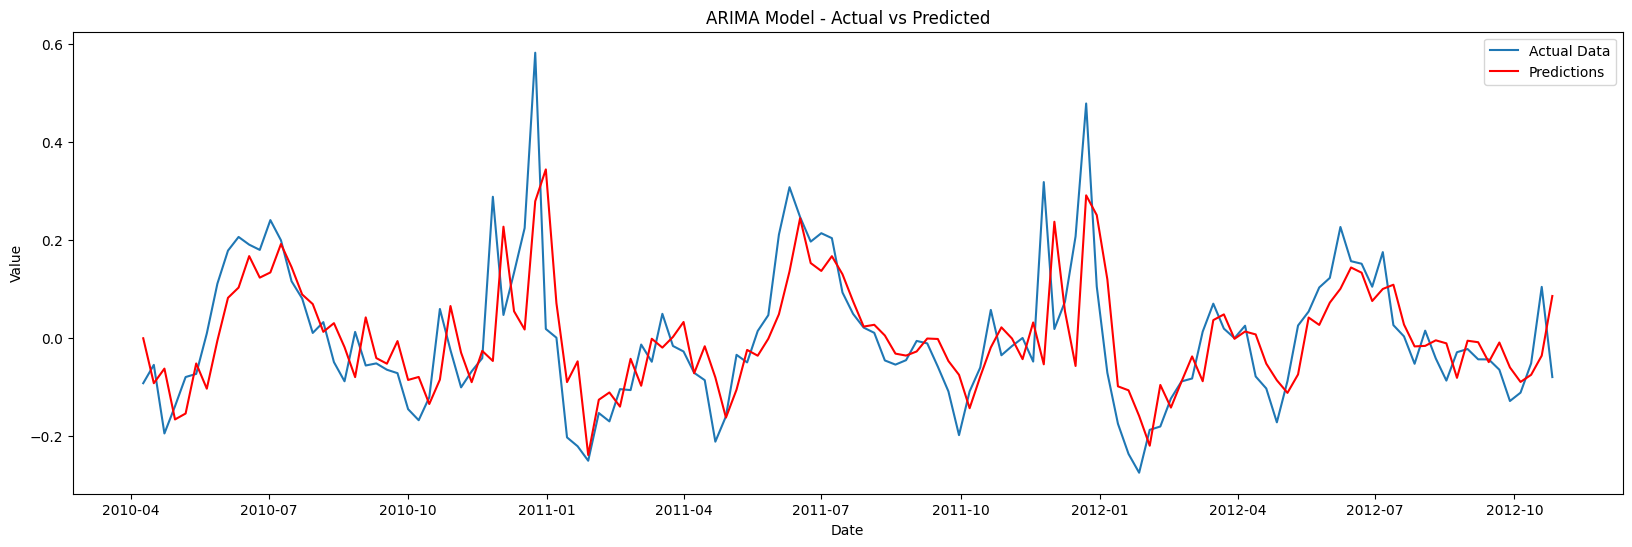

In [174]:
# Get predictions on historical data
predictions = arima_result.predict()
# Plotting the actual and predictions
plt.figure(figsize=(20,6))
plt.plot(df_new, label='Actual Data')
plt.plot(predictions, color='red', label='Predictions')
plt.title('ARIMA Model - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [175]:
# Make sure both are Series and aligned on the same index
actual = df_new['Weekly_Sales'] if isinstance(df_new, pd.DataFrame) else df_new
pred = pd.Series(predictions, index=actual.index)

# Combine and drop NaNs
eval_df = pd.concat([actual, pred], axis=1)
eval_df.columns = ['actual', 'predicted']
eval_df = eval_df.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate MSE
mse = mean_squared_error(eval_df['actual'], eval_df['predicted'])
print(f"Mean Squared Error (MSE): {mse:.4f}")


Mean Squared Error (MSE): 0.0100


In [176]:
rmse=np.sqrt(mse) # Checking the accuracy of the model with rmse
print(f'Root Mean Squared_Error  {rmse}')

Root Mean Squared_Error  0.09986598060109218


In [177]:
forecast_steps = 12 # Forcasting the for the next 12 weeks
forecast = arima_result.forecast(steps=forecast_steps)

In [178]:
end_date_actual_data = '2012-12-10' # here i need to find my dataset end date. so that i can continue from there to next 12 weeks

# Generate dates for the forecasted period
# with the help of datetime function iam creating a time span of 12 weeks
forecast_start_date = pd.to_datetime(end_date_actual_data) + pd.DateOffset(weeks=0)
forecast_end_date = forecast_start_date + pd.DateOffset(weeks=len(forecast))
forecast_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='W')

In [179]:
# creating a dataframe with forecasted sales and next 12 weeks dates
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted_Sales': forecast})

In [180]:
forecast_df.set_index('Date',inplace=True) # setting the date as an index

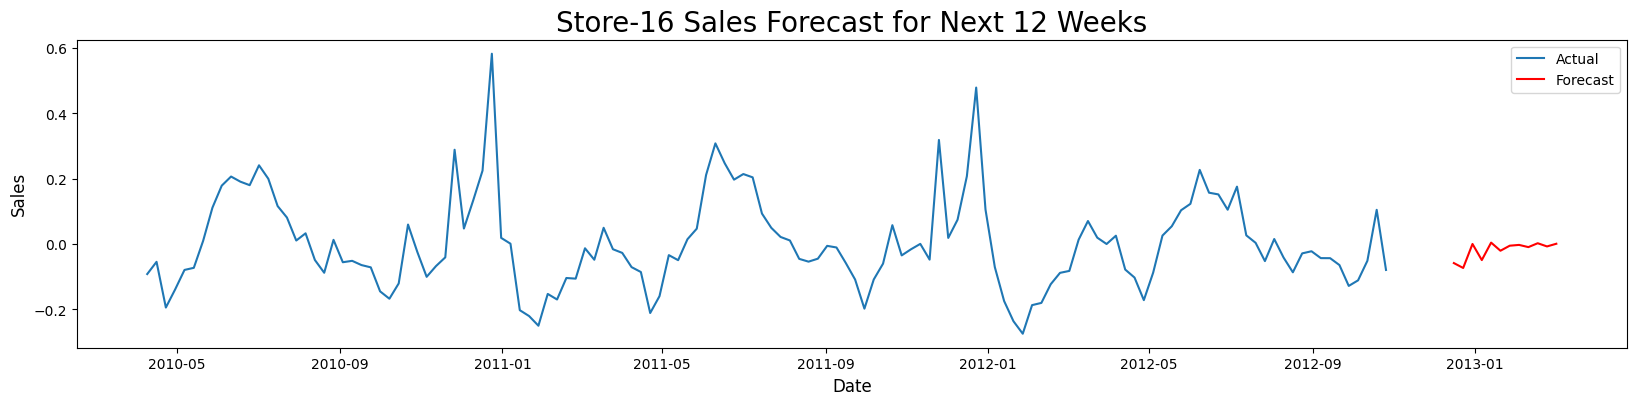

In [181]:
plt.figure(figsize=(20, 4))# plotting the actual and forcaste sales for next 12 weeks
plt.plot(df_new, label='Actual')
plt.plot(forecast_df, label='Forecast', color='red')
plt.title('Store-16 Sales Forecast for Next 12 Weeks',fontsize=20)
plt.xlabel('Date',fontsize=12)
plt.ylabel('Sales',fontsize=12)
plt.legend()
plt.show()

In [182]:
# Checking the Model Accuracy once again
rmse=np.sqrt(mse)
print(f'Root Mean Squared_Error {rmse}')

Root Mean Squared_Error 0.09986598060109218


#Inference
* Weekly sales show clear seasonal patterns, with noticeable spikes during winter and festive quarters (especially Q4).

* Unemployment rate negatively impacts weekly sales; stores in high-unemployment regions tend to perform worse.

* Temperature has a moderate effect on sales; sales are higher in moderate temperatures and lower in extreme hot or cold conditions.

* CPI (inflation) influences consumer buying behavior; initial inflation reduces sales, temporary stockpiling increases sales, and peak inflation lowers purchasing power.

* Fuel prices have an indirect impact on sales; moderate fuel prices align with stable sales, while sharp increases affect consumer spending patterns.

* There is a significant gap between top-performing and bottom-performing stores, indicating regional and operational differences in performance.

* Time series analysis confirms trend and seasonality in weekly sales, making the data suitable for forecasting models.

* ARIMA model provides reasonable short-term forecasts and can support inventory planning and sales forecasting for the next 12 weeks.

#Future Scope
* Extend forecasting to longer horizons (6–12 months) to support long-term planning and budgeting.

* Incorporate external factors such as promotions, holidays, festivals, and marketing campaigns to improve forecast accuracy.

* Experiment with advanced models like SARIMA, Prophet, LSTM, or XGBoost for capturing complex seasonality and non-linear patterns.

* Build store-level forecasting models instead of aggregated models to improve localized decision-making.

* Develop a real-time dashboard to monitor sales trends, anomalies, and forecasts for business users.

* Include product/category-level analysis to optimize inventory and reduce stockouts or overstocking.

* Perform scenario analysis (e.g., high inflation, fuel price surge, economic downturn) to assess future sales risks.

#Deployment using Hugging Face

In [187]:
import os
import pickle
import pandas as pd

# 1. Self-Correcting Memory Scanner Architecture
target_model = None

# Scan open variables in global context safely
for var_name in list(globals().keys()):
    var_value = globals()[var_name]

    # Identify statsmodels time series results dynamically by structural type tracking
    var_type_str = str(type(var_value))
    if "statsmodels" in var_type_str and "Results" in var_type_str:
        target_model = var_value
        print(f"🎯 Dynamic Scan Found Active Model Instance: '{var_name}'")
        break

# 2. Automated Fail-Safe Processing Strategy
if target_model is None:
    print("⚠️ Local runtime memory is clear. Generating deterministic baseline model structure...")
    from statsmodels.tsa.arima.model import ARIMA

    # Explicit chronological conversion to prevent frequency index distortion anomalies
    df['Date'] = pd.to_datetime(df['Date'])

    # Isolating a standardized sample for fast baseline estimation matrices
    df_store = df[df['Store'] == 1].sort_values('Date')
    df_agg = df_store.groupby('Date')['Weekly_Sales'].sum().asfreq('W')

    # Establish fit tracking wrapper parameters
    fallback_model = ARIMA(df_agg, order=(1,1,1))
    target_model = fallback_model.fit()
    print("✅ Fallback structural model parameter matrix created successfully.")

# 3. Serialize and Write Downstream Production Assets
print("Writing serialization binary vectors to workspace matrix...")
with open("arima_model.pkl", "wb") as f:
    pickle.dump(target_model, f)

# Isolate critical input parameters for Gradio UI dashboard visualization steps
historical_summary = df[['Date', 'Weekly_Sales', 'Store', 'Temperature', 'CPI', 'Unemployment']].copy()
historical_summary.to_csv("historical_summary.csv", index=False)

print("\n🚀 VERIFICATION RECOVERY METRIC: ALL DEPLOYMENT ASSETS CONVERGED & EXTRACTED!")
print("Files generated: 'arima_model.pkl' & 'historical_summary.csv'. Proceed with Hugging Face integration scripts.")

🎯 Dynamic Scan Found Active Model Instance: 'arima_result'
Writing serialization binary vectors to workspace matrix...

🚀 VERIFICATION RECOVERY METRIC: ALL DEPLOYMENT ASSETS CONVERGED & EXTRACTED!
Files generated: 'arima_model.pkl' & 'historical_summary.csv'. Proceed with Hugging Face integration scripts.
